In [ ]:
# ===== CELL 1: Install Times New Roman (for 600 dpi / EPS figures) =====
!apt-get -qq update > /dev/null 2>&1
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!apt-get -qq install -y ttf-mscorefonts-installer > /dev/null 2>&1
!fc-cache -f > /dev/null 2>&1

# Verify it actually landed on disk (this is the part that silently fails sometimes)
!fc-list | grep -i "times new roman" || echo "NOT FOUND - will need Runtime > Restart session and rerun"


/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf: Times New Roman:style=Regular,Normal,obyčejné,Standard,Κανονικά,Normaali,Normál,Normale,Standaard,Normalny,Обычный,Normálne,Navadno,thường,Arrunta
/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Italic.ttf: Times New Roman:style=Italic,cursiva,kurzíva,kursiv,Πλάγια,Kursivoitu,Italique,Dőlt,Corsivo,Cursief,kursywa,Itálico,Курсив,İtalik,Poševno,nghiêng,Etzana
/usr/share/fonts/truetype/msttcorefonts/timesbd.ttf: Times New Roman:style=Bold,Negreta,tučné,fed,Fett,Έντονα,Negrita,Lihavoitu,Gras,Félkövér,Grassetto,Vet,Halvfet,Pogrubiona,Negrito,Полужирный,Fet,Kalın,Krepko,đậm,Lodia
/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold_Italic.ttf: Times New Roman:style=Bold Italic,Negreta cursiva,tučné kurzíva,fed kursiv,Fett Kursiv,Έντονα Πλάγια,Negrita Cursiva,Lihavoitu Kursivoi,Gras Italique,Félkövér dőlt,Grassetto Corsivo,Vet Cursief,Halvfet Kursiv,Pogrubiona kursywa,Negrito Itálico,Полужирный Курсив,Tučná kurzíva

In [ ]:
# ===== CELL 1b: Fallback font download (in case apt install fails) =====
!wget -q -O /content/TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
!wget -q -O /content/times.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/times.ttf
!wget -q -O /content/timesbd.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/timesbd.ttf


In [ ]:
!pip install -q tensorflow scikit-learn seaborn matplotlib


In [ ]:
# ===== CELL 2: Imports, font config, plot/save configuration =====
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
)

# Rebuild matplotlib's font cache so it picks up the just-installed font
for f in os.listdir(matplotlib.get_cachedir()):
    if 'fontlist' in f:
        os.remove(os.path.join(matplotlib.get_cachedir(), f))
fm.fontManager = fm.FontManager()

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13

PLOT_DIR = "/content/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

def save_plot(fig, name):
    """Save a figure at 600 dpi in EPS format, per CS3807 lab conventions."""
    path = os.path.join(PLOT_DIR, f"{name}.eps")
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved: {path}")

print("Configured font.serif priority:", plt.rcParams['font.serif'][:3])

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


Configured font.serif priority: ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif']
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ===== CELL 3: Load dataset =====
print("Loading CIFAR-10 ...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(f"Train set : {x_train.shape}, labels {y_train.shape}")
print(f"Test set  : {x_test.shape}, labels {y_test.shape}")


Loading CIFAR-10 ...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1611s 9us/step
Train set : (50000, 32, 32, 3), labels (50000, 1)
Test set  : (10000, 32, 32, 3), labels (10000, 1)


/tmp/ipykernel_655/897935957.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[CLASS_NAMES[i] for i in unique], y=counts, palette="viridis", ax=ax)


Saved: /content/plots/01_class_distribution_train.eps


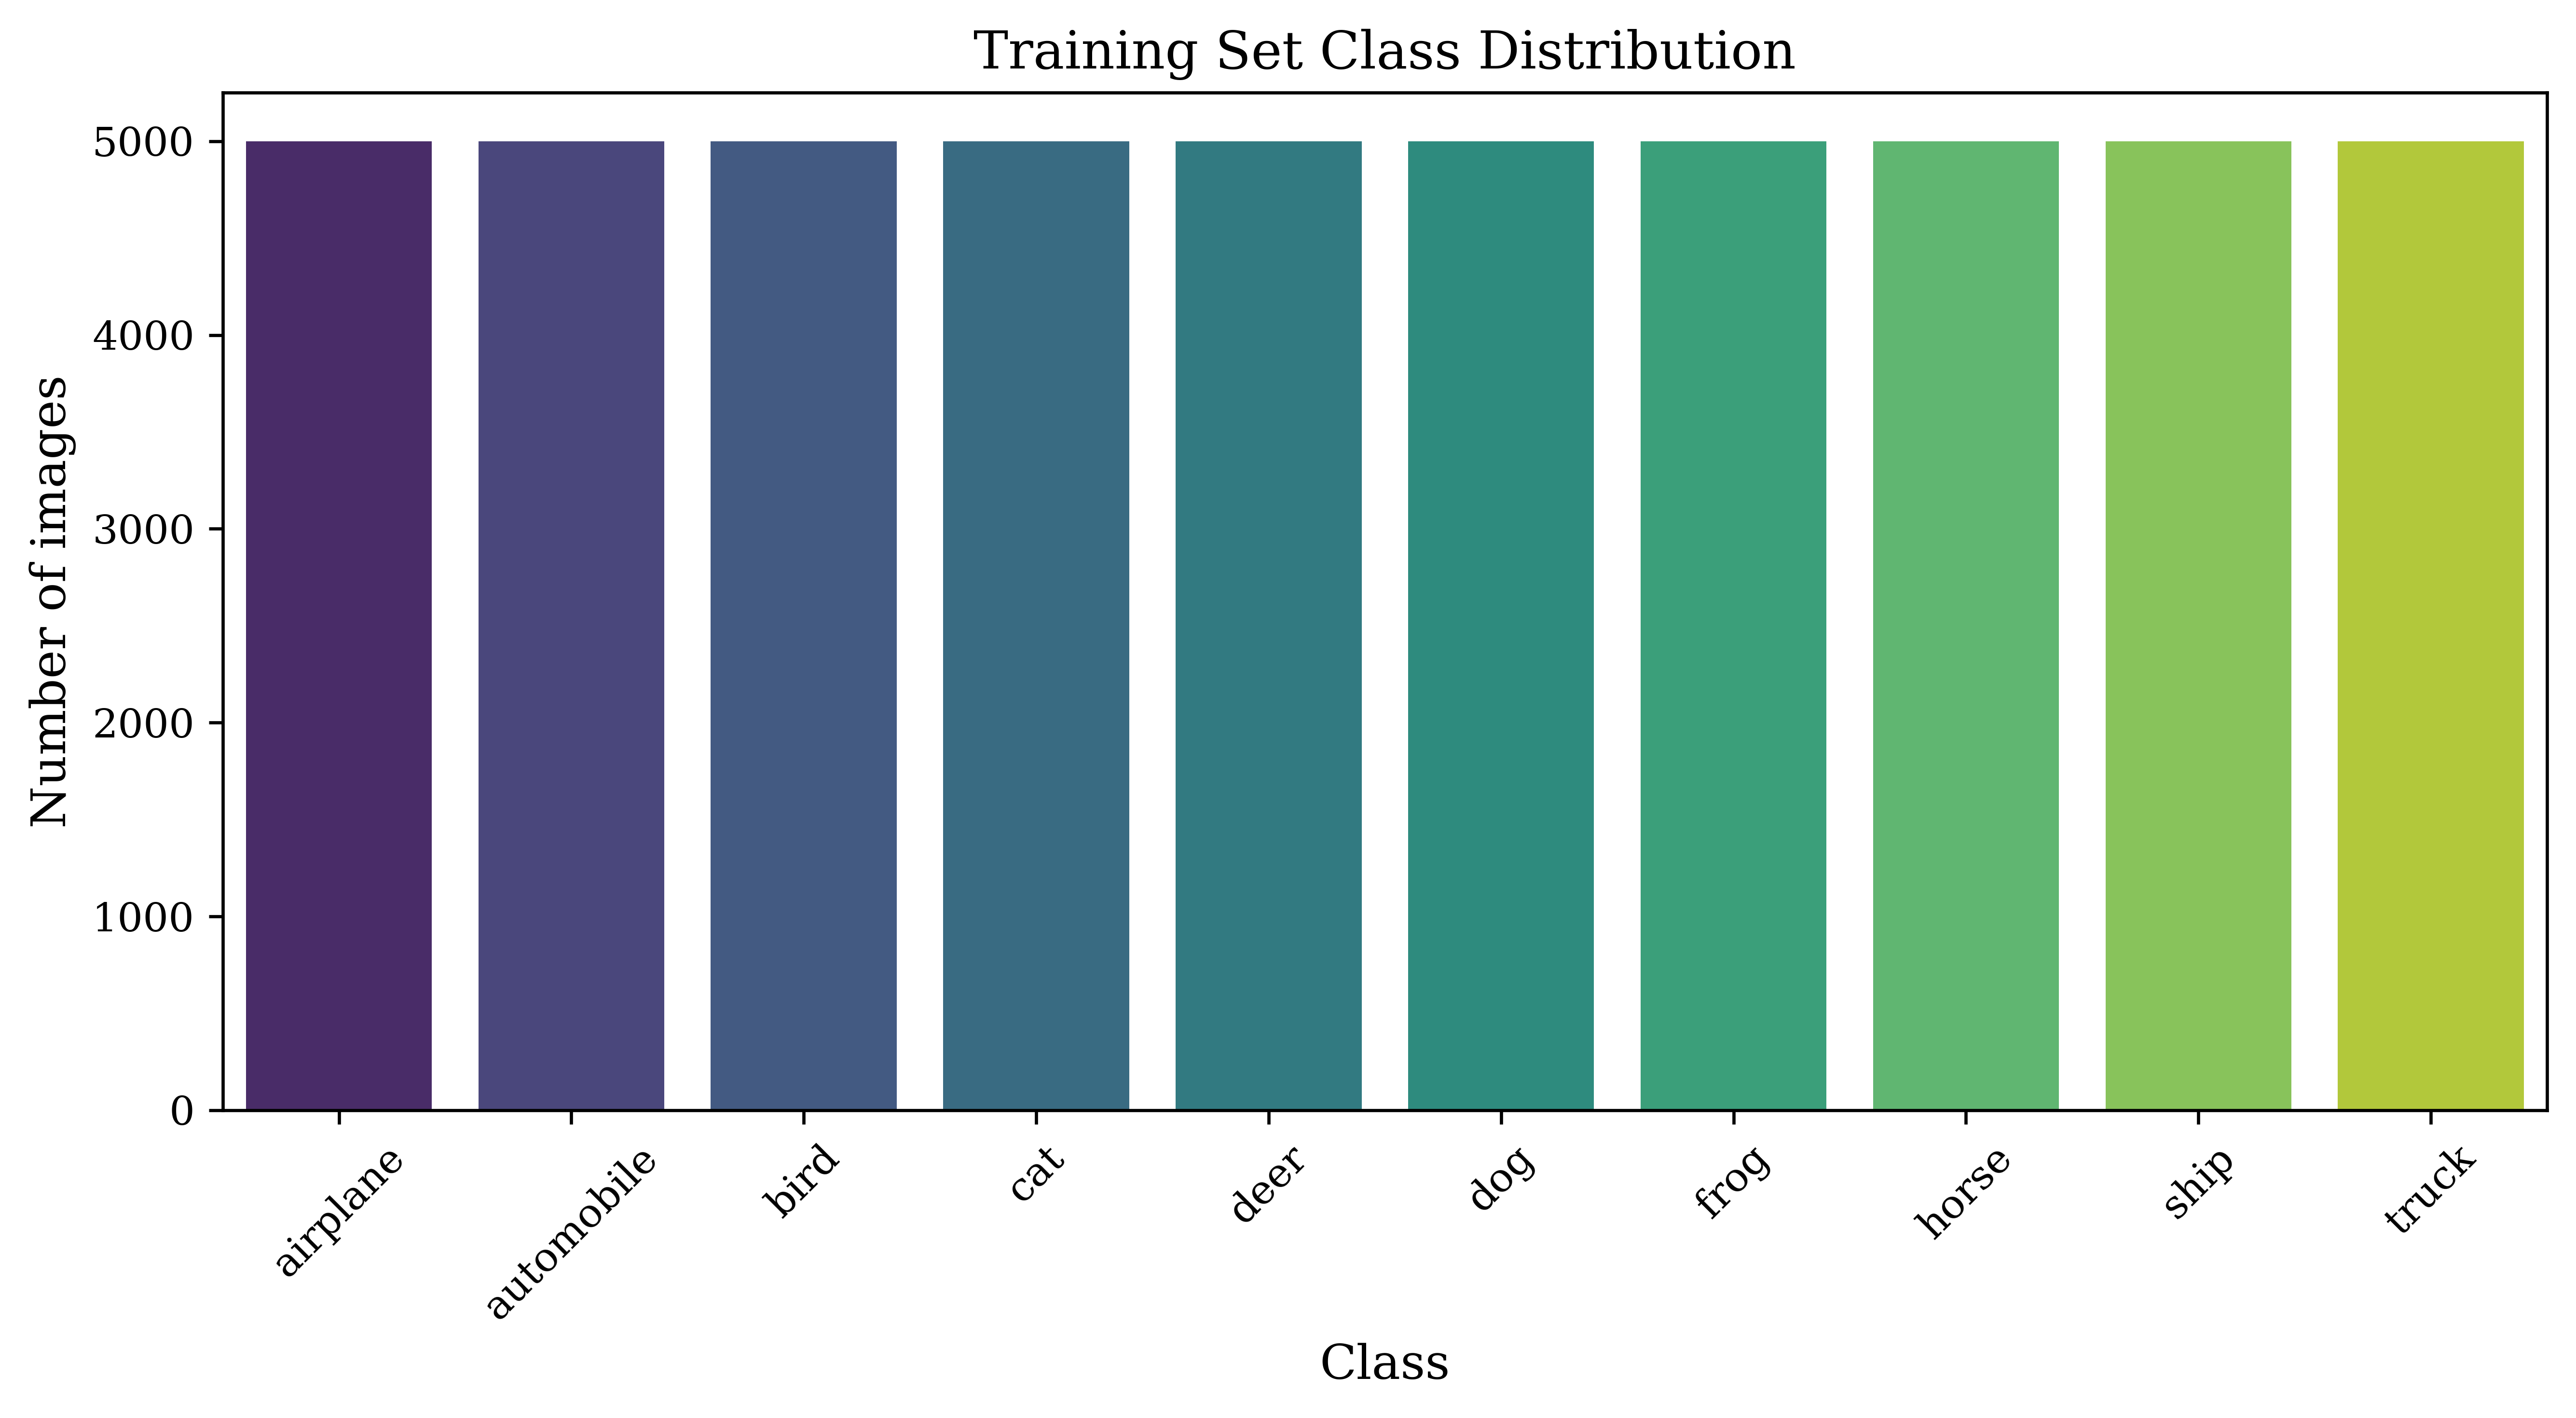

/tmp/ipykernel_655/897935957.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[CLASS_NAMES[i] for i in unique], y=counts, palette="viridis", ax=ax)


Saved: /content/plots/02_class_distribution_test.eps


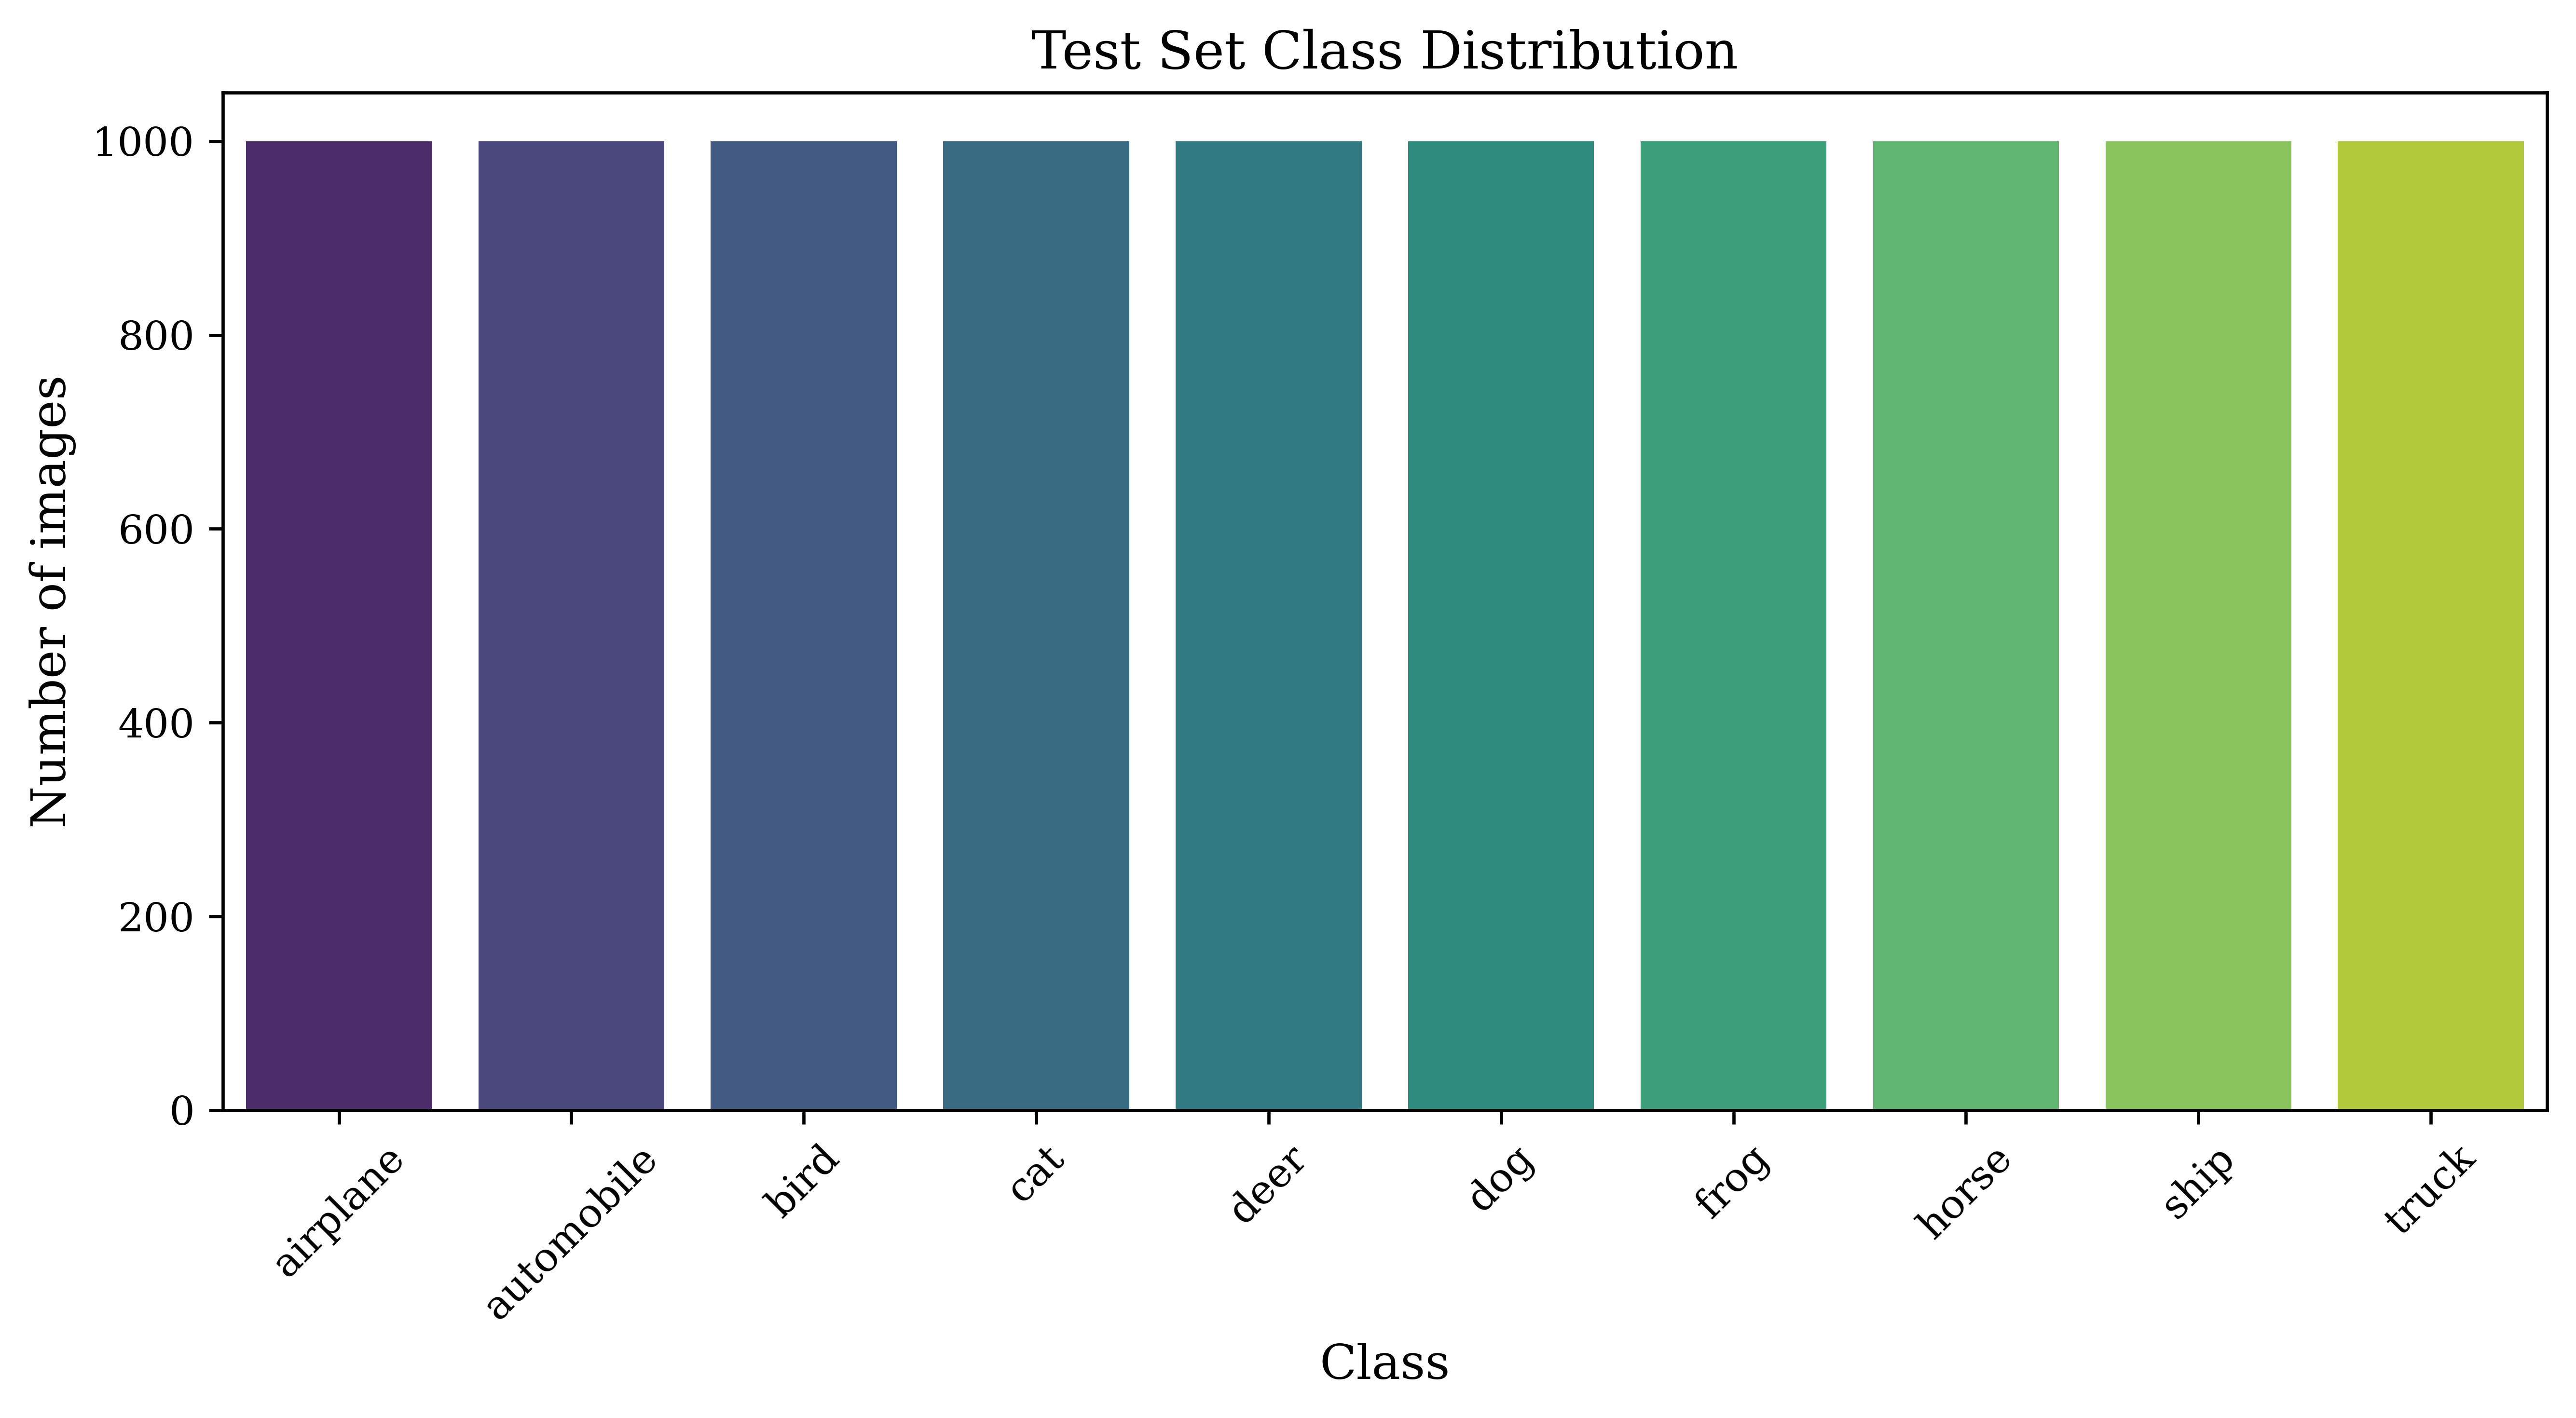

In [ ]:
# ===== CELL 4: Class distribution plots =====
def plot_class_distribution(y, title, filename):
    unique, counts = np.unique(y, return_counts=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(x=[CLASS_NAMES[i] for i in unique], y=counts, palette="viridis", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of images")
    ax.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()

plot_class_distribution(y_train.flatten(), "Training Set Class Distribution", "01_class_distribution_train")
plot_class_distribution(y_test.flatten(), "Test Set Class Distribution", "02_class_distribution_test")


Saved: /content/plots/03_sample_images.eps


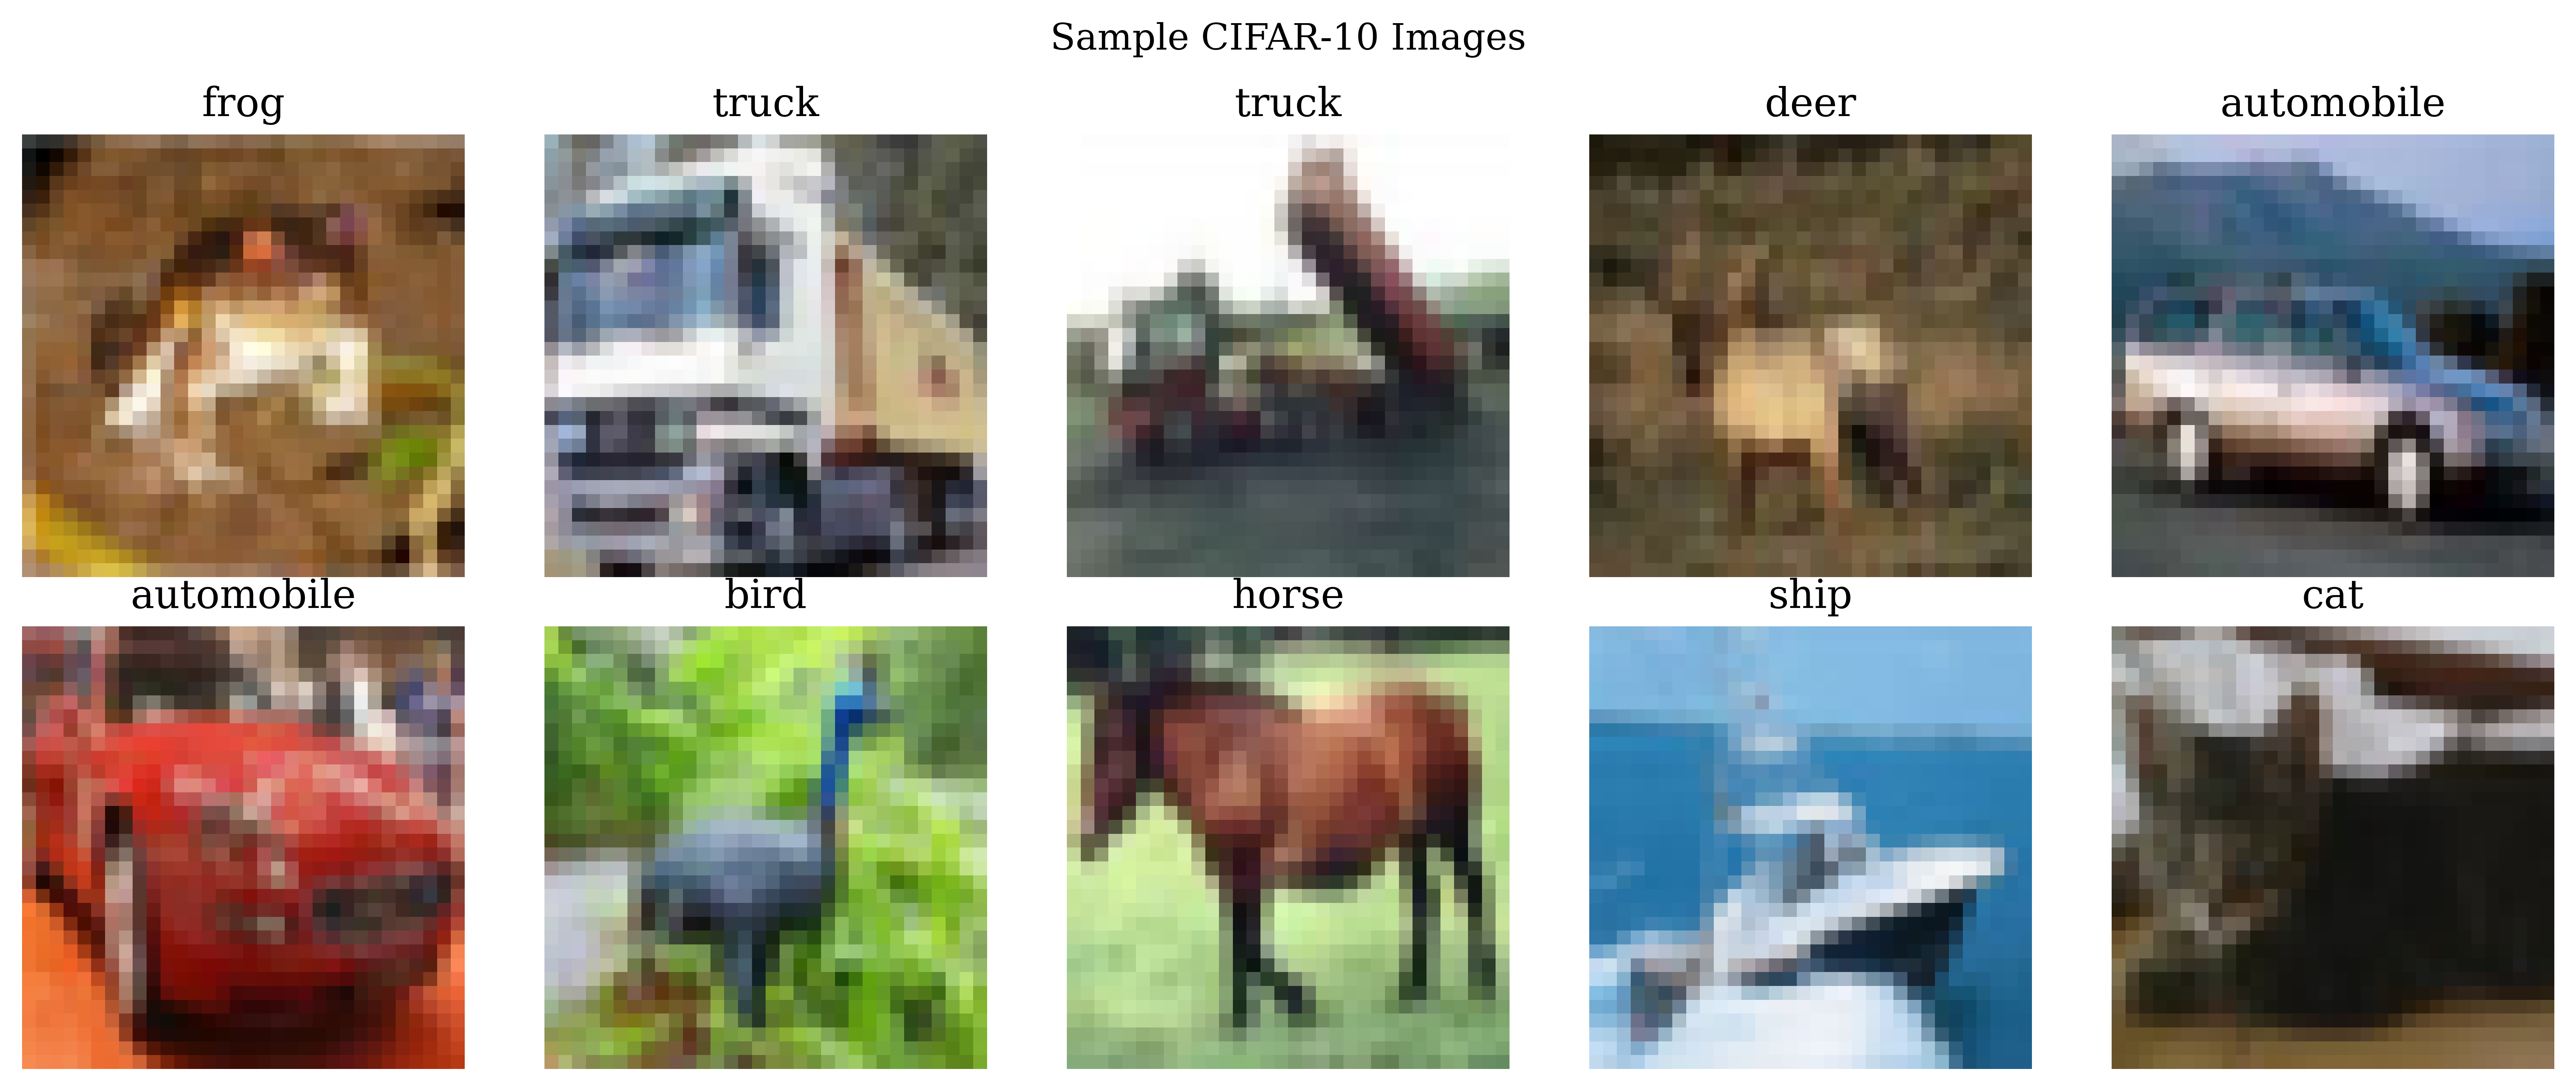

In [ ]:
# ===== CELL 5: Sample image grid =====
def plot_sample_images(x, y, filename, n=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(x[i])
        ax.set_title(CLASS_NAMES[int(y[i])])
        ax.axis("off")
    fig.suptitle("Sample CIFAR-10 Images")
    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()

plot_sample_images(x_train, y_train.flatten(), "03_sample_images")


In [ ]:
# ===== CELL 6: Preprocessing =====
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Hold out a validation split from the training data
val_frac = 0.1
n_val = int(len(x_train_norm) * val_frac)
x_val, y_val = x_train_norm[:n_val], y_train_cat[:n_val]
x_tr, y_tr = x_train_norm[n_val:], y_train_cat[n_val:]

print("Train:", x_tr.shape, "Val:", x_val.shape, "Test:", x_test_norm.shape)


Train: (45000, 32, 32, 3) Val: (5000, 32, 32, 3) Test: (10000, 32, 32, 3)


In [ ]:
def build_cnn(
    input_shape=(32, 32, 3),
    num_classes=10,
    filters=(32, 64),
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="same",
    pooling="max",
    pool_size=(2, 2),
    dense_units=128,
    optimizer_name="adam",
    learning_rate=1e-3,
):
    PoolLayer = layers.MaxPooling2D if pooling == "max" else layers.AveragePooling2D

    model = models.Sequential(name=f"CNN_{pooling}_k{kernel_size[0]}_s{strides[0]}")
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(
        filters=filters[0], kernel_size=kernel_size, strides=strides,
        padding=padding, activation="relu", name="conv2d_1"
    ))
    model.add(PoolLayer(pool_size=pool_size, padding="same", name="pool_1"))
    model.add(layers.Conv2D(
        filters=filters[1], kernel_size=kernel_size, strides=strides,
        padding=padding, activation="relu", name="conv2d_2"
    ))
    model.add(PoolLayer(pool_size=pool_size, padding="same", name="pool_2"))
    model.add(layers.Flatten(name="flatten"))
    model.add(layers.Dense(dense_units, activation="relu", name="dense_1"))
    model.add(layers.Dense(num_classes, activation="softmax", name="output"))

    if optimizer_name == "adam":
        opt = optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name == "rmsprop":
        opt = optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def conv_output_dim(n, k, s=1, p=0):
    return int(np.floor((n - k + 2 * p) / s) + 1)


## 3. Required CNN Model

In [ ]:
baseline_model = build_cnn(
    filters=(32, 64),
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="same",
    pooling="max",
    optimizer_name="adam",
    learning_rate=1e-3,
)
baseline_model.summary()


Model: "CNN_max_k3_s1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

### 3a. Trainable parameter analysis

In [ ]:
def analyze_trainable_params(model, filename="04_trainable_params.txt"):
    lines = [f"{'Layer':25s} {'Output Shape':22s} {'Param #':>10s}"]
    for layer in model.layers:
        params = layer.count_params()
        try:
            shape = str(layer.output.shape)
        except Exception:
            shape = "N/A"
        lines.append(f"{layer.name:25s} {shape:22s} {params:>10d}")
    lines.append(f"\nTotal trainable parameters: {model.count_params()}")
    text = "\n".join(lines)
    print(text)
    with open(os.path.join(PLOT_DIR, filename), "w") as f:
        f.write(text)

analyze_trainable_params(baseline_model)


Layer                     Output Shape              Param #
conv2d_1                  (None, 32, 32, 32)            896
pool_1                    (None, 16, 16, 32)              0
conv2d_2                  (None, 16, 16, 64)          18496
pool_2                    (None, 8, 8, 64)                0
flatten                   (None, 4096)                    0
dense_1                   (None, 128)                524416
output                    (None, 10)                   1290

Total trainable parameters: 545098


In [ ]:
BATCH_SIZE = 32
EPOCHS = 20

history = baseline_model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=2,
)


Epoch 1/20
1407/1407 - 12s - 8ms/step - accuracy: 0.5063 - loss: 1.3829 - val_accuracy: 0.6130 - val_loss: 1.0944
Epoch 2/20
1407/1407 - 6s - 4ms/step - accuracy: 0.6478 - loss: 1.0072 - val_accuracy: 0.6408 - val_loss: 1.0104
Epoch 3/20
1407/1407 - 5s - 4ms/step - accuracy: 0.6990 - loss: 0.8625 - val_accuracy: 0.6498 - val_loss: 0.9812
Epoch 4/20
1407/1407 - 6s - 4ms/step - accuracy: 0.7354 - loss: 0.7581 - val_accuracy: 0.6560 - val_loss: 0.9900
Epoch 5/20
1407/1407 - 10s - 7ms/step - accuracy: 0.7677 - loss: 0.6676 - val_accuracy: 0.6540 - val_loss: 1.0242
Epoch 6/20
1407/1407 - 5s - 4ms/step - accuracy: 0.7983 - loss: 0.5805 - val_accuracy: 0.6766 - val_loss: 1.0080
Epoch 7/20
1407/1407 - 5s - 4ms/step - accuracy: 0.8251 - loss: 0.5045 - val_accuracy: 0.6818 - val_loss: 1.0524
Epoch 8/20
1407/1407 - 6s - 4ms/step - accuracy: 0.8500 - loss: 0.4339 - val_accuracy: 0.6640 - val_loss: 1.2253
Epoch 9/20
1407/1407 - 5s - 4ms/step - accuracy: 0.8688 - loss: 0.3797 - val_accuracy: 0.6740 

Saved: /content/plots/05_training_curves.eps


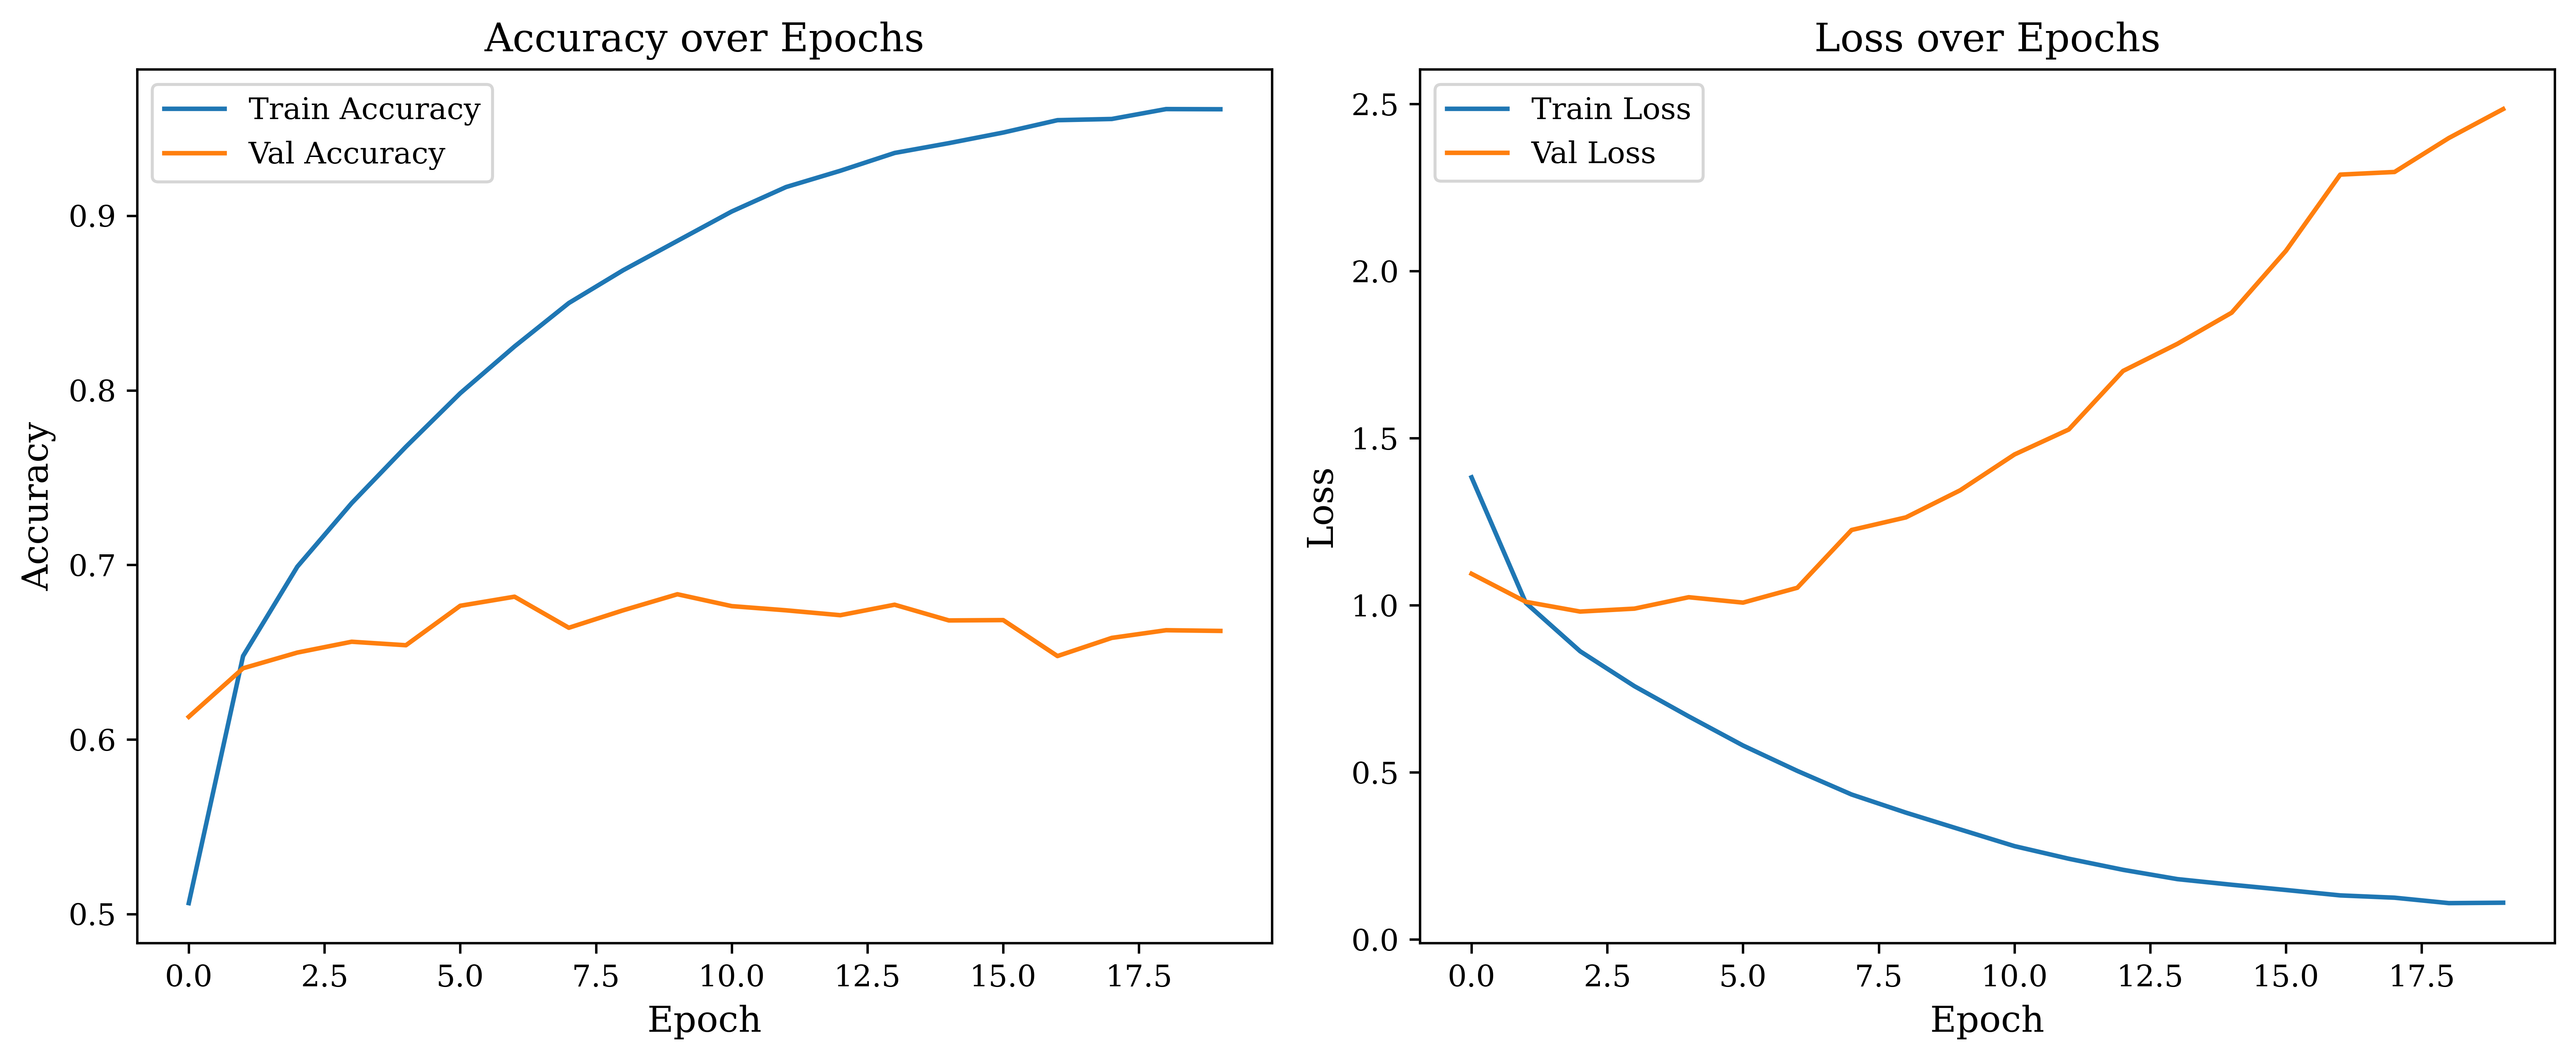

In [ ]:
# ===== CELL 11: Training curves =====
def plot_history(history, filename="05_training_curves"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(history.history["accuracy"], label="Train Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[0].set_title("Accuracy over Epochs")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

    axes[1].plot(history.history["loss"], label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Val Loss")
    axes[1].set_title("Loss over Epochs")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()

plot_history(history)


In [ ]:
# ===== CELL 12: Metrics + classification report =====
y_pred_probs = baseline_model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

test_acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print(f"Test Accuracy    : {test_acc:.4f}")
print(f"Precision(macro) : {precision:.4f}")
print(f"Recall(macro)    : {recall:.4f}")
print(f"F1-score(macro)  : {f1:.4f}\n")

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)

with open(os.path.join(PLOT_DIR, "06_classification_report.txt"), "w") as f:
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Precision(macro): {precision:.4f}\nRecall(macro): {recall:.4f}\nF1(macro): {f1:.4f}\n\n")
    f.write(report)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test Accuracy    : 0.6582
Precision(macro) : 0.6703
Recall(macro)    : 0.6582
F1-score(macro)  : 0.6580

              precision    recall  f1-score   support

    airplane       0.66      0.77      0.71      1000
  automobile       0.81      0.67      0.73      1000
        bird       0.60      0.52      0.56      1000
         cat       0.44      0.51      0.47      1000
        deer       0.57      0.64      0.60      1000
         dog       0.62      0.49      0.55      1000
        frog       0.84      0.60      0.70      1000
       horse       0.69      0.79      0.74      1000
        ship       0.83      0.76      0.79      1000
       truck       0.65      0.83      0.73      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



Saved: /content/plots/07_confusion_matrix.eps


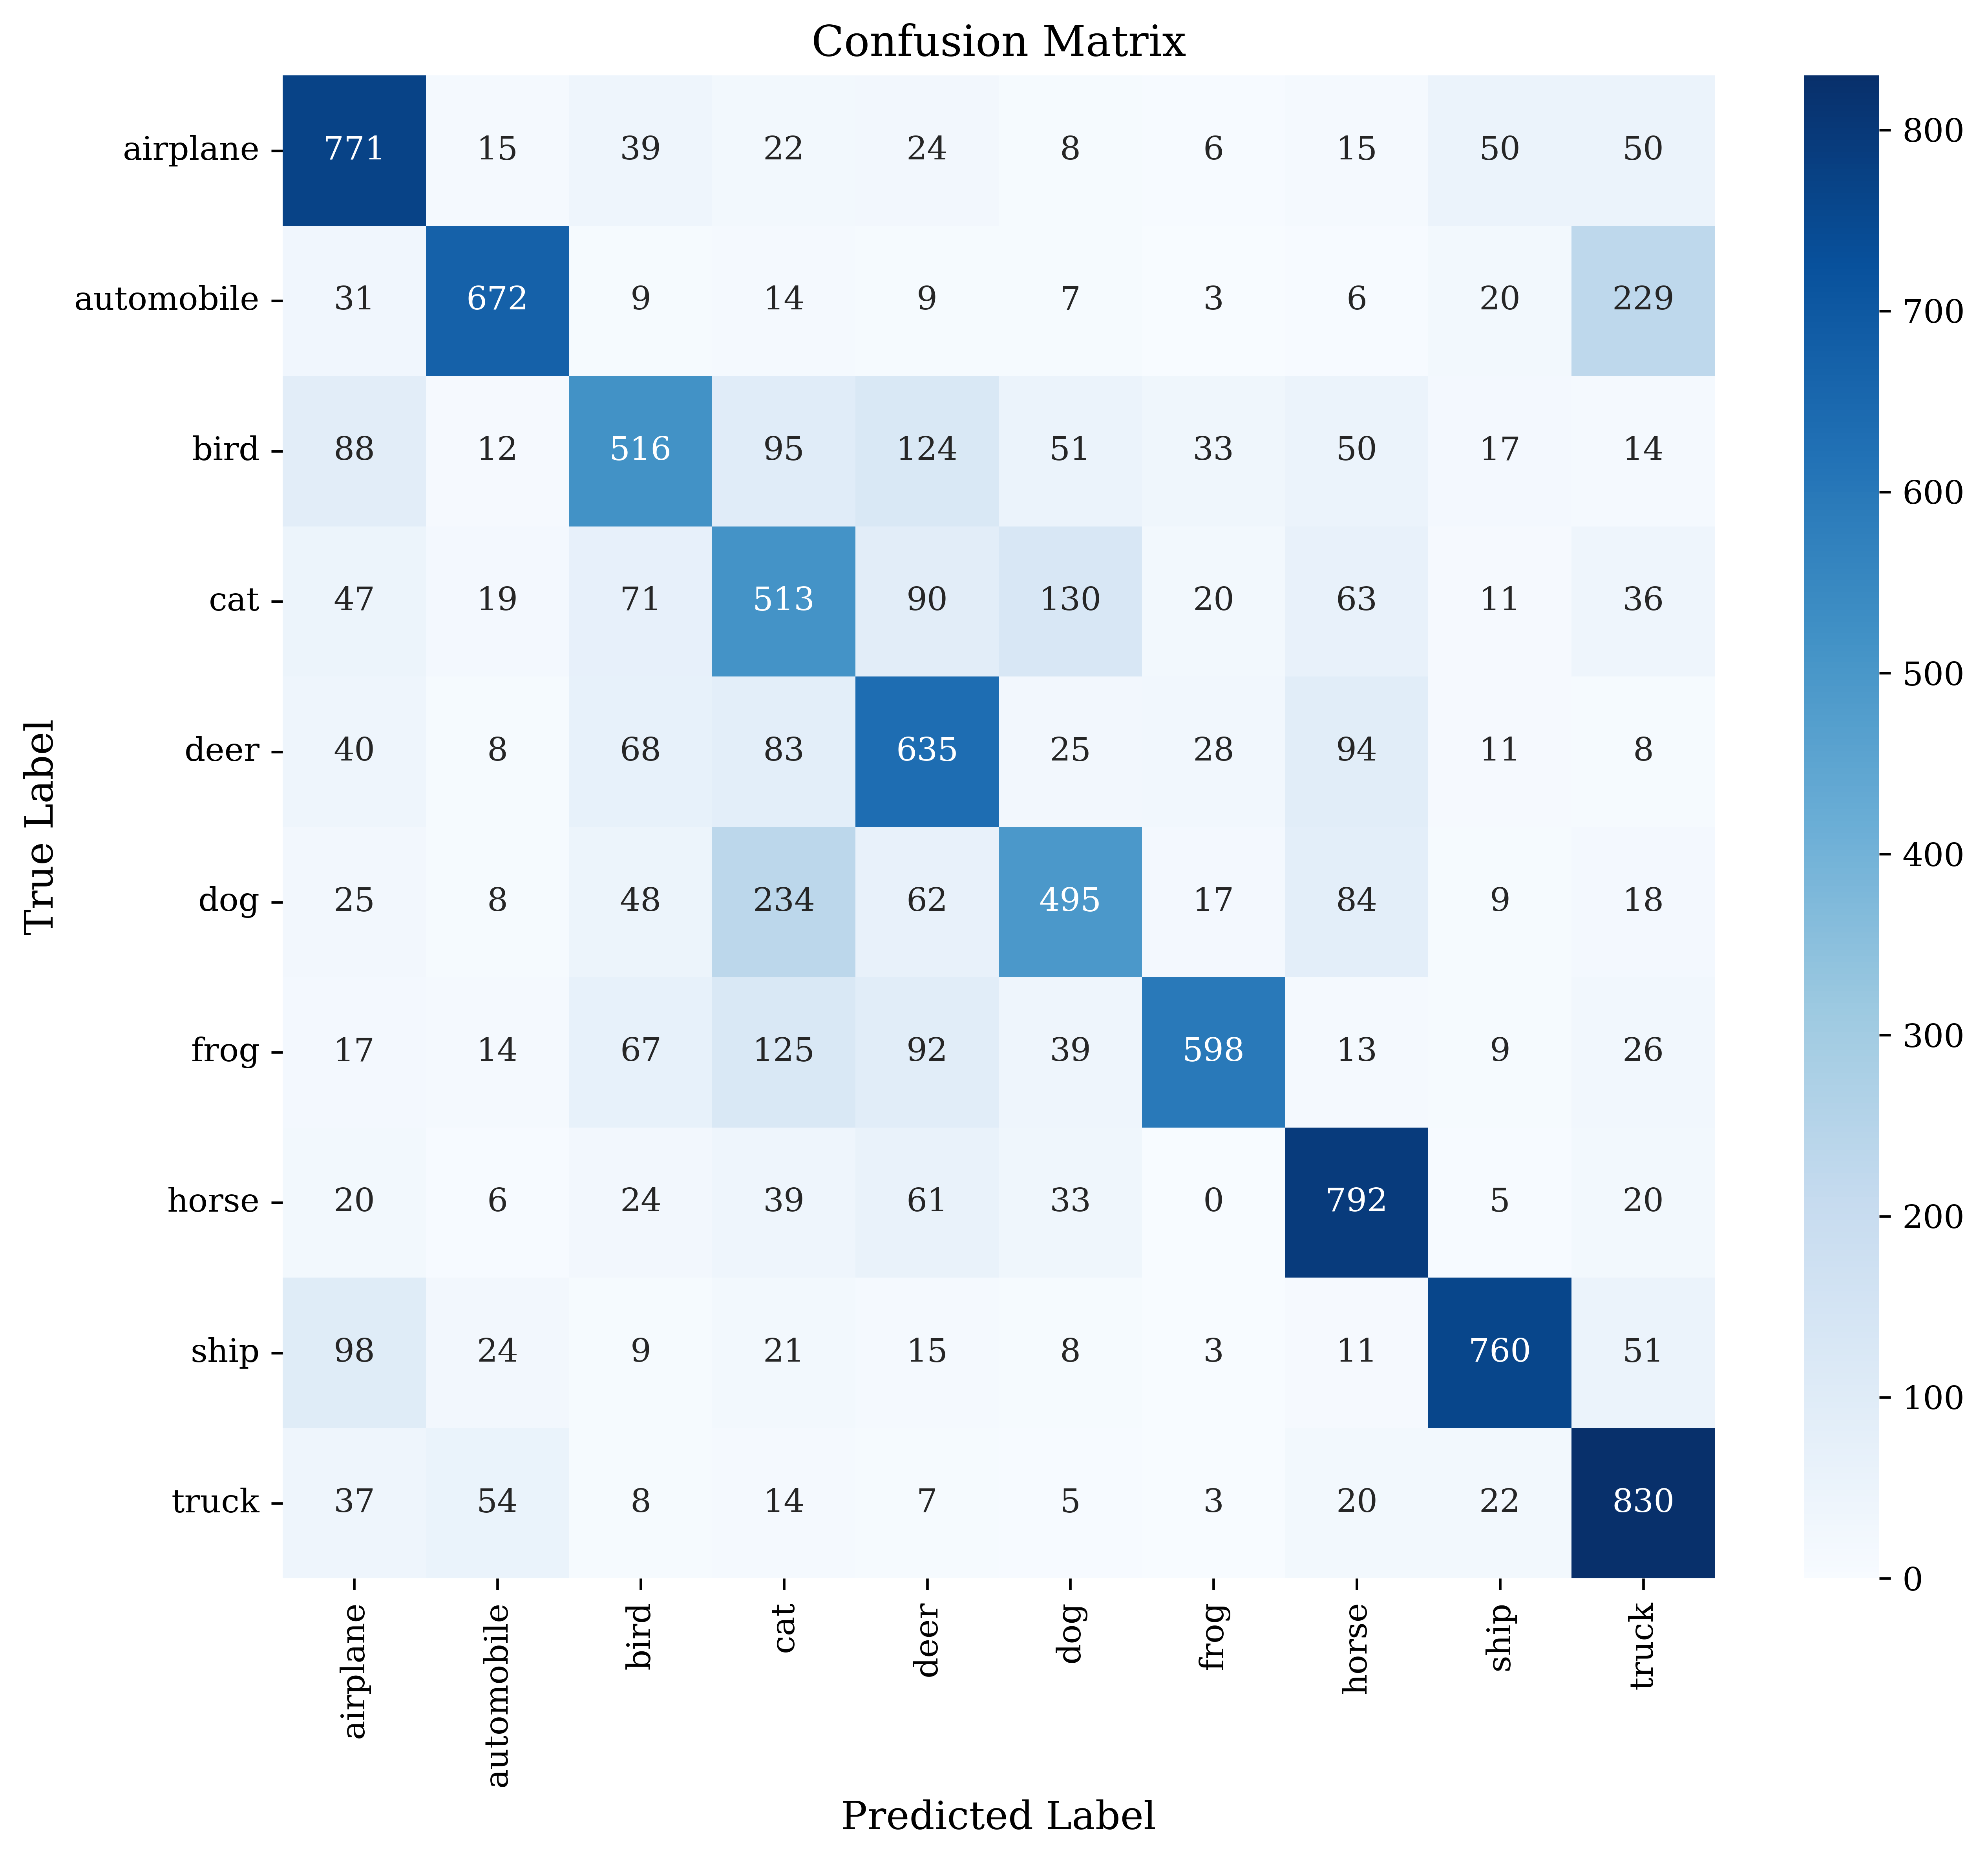

In [ ]:
# ===== CELL 13: Confusion matrix =====
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
fig.tight_layout()
save_plot(fig, "07_confusion_matrix")
plt.show()


Saved: /content/plots/08_sobel_edges.eps


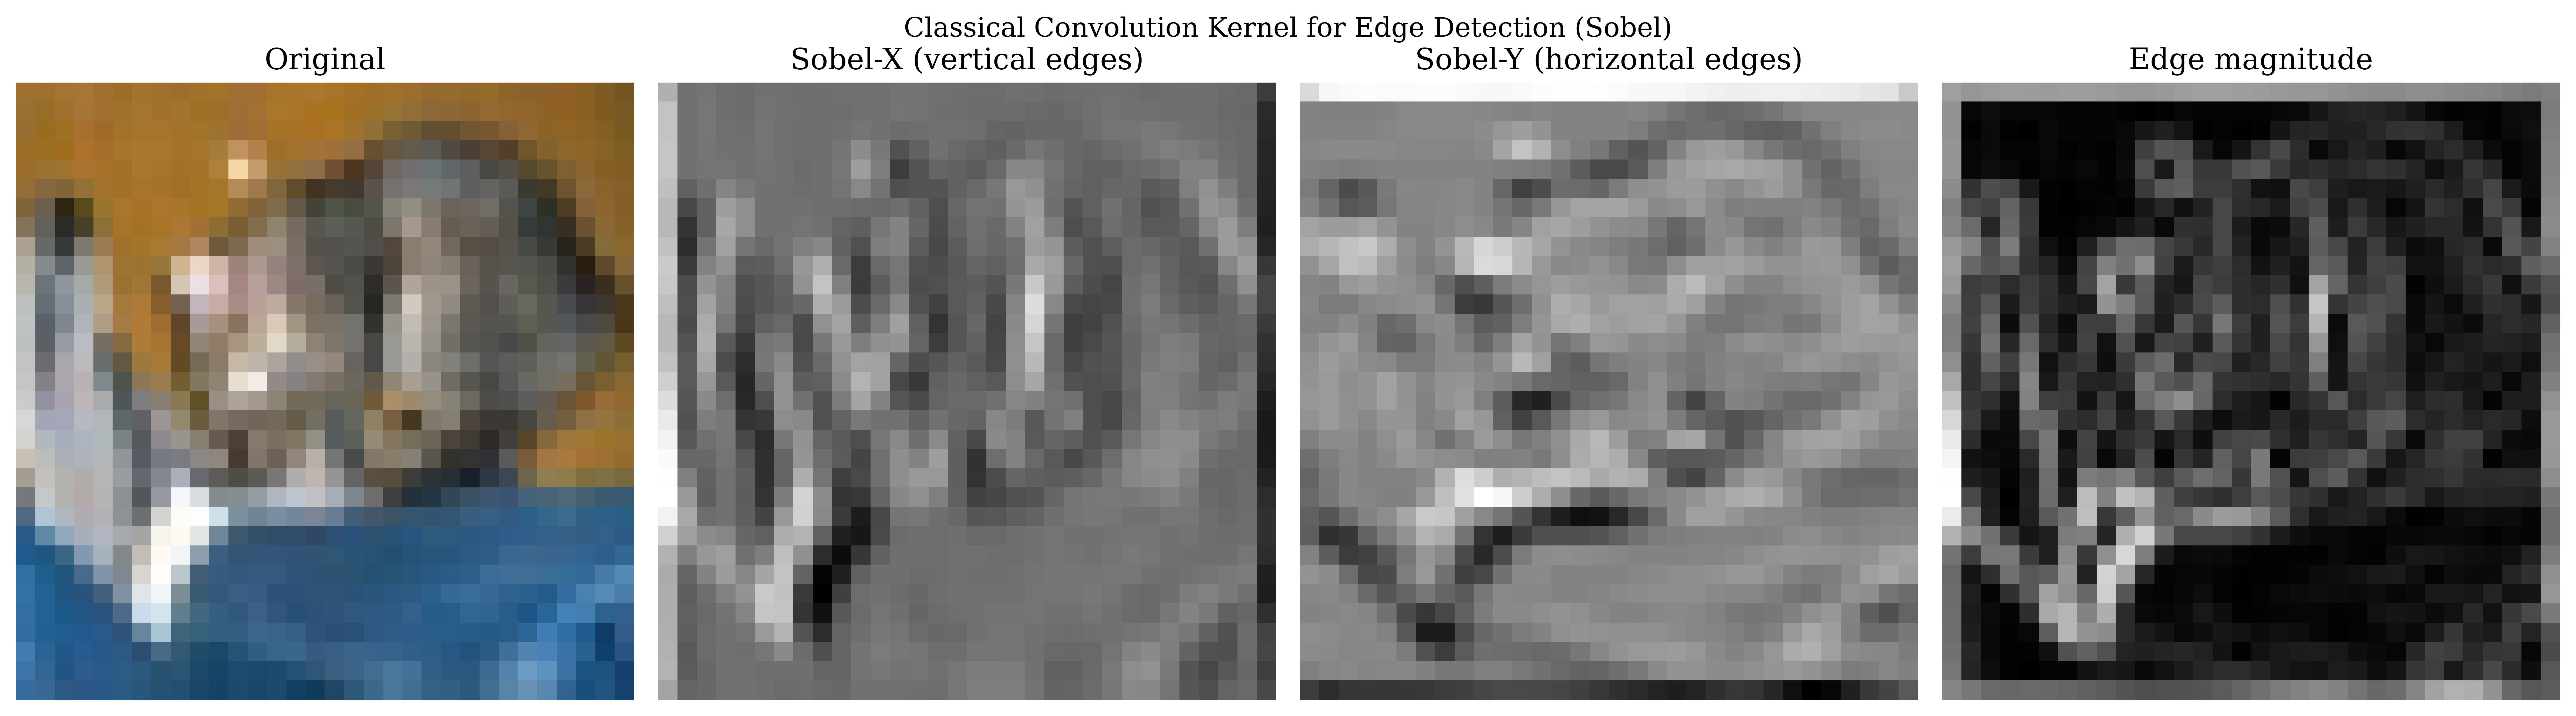

In [ ]:
# ===== CELL 14a: Classical Sobel edge detection (ground-truth "edges" demo) =====
def sobel_edge_demo(image, filename="08_sobel_edges"):
    gray = np.dot(image[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.float32)
    gray_t = tf.constant(gray.reshape(1, gray.shape[0], gray.shape[1], 1))

    sobel_x = tf.constant([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=tf.float32)
    sobel_y = tf.constant([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=tf.float32)
    kernel_x = tf.reshape(sobel_x, [3, 3, 1, 1])
    kernel_y = tf.reshape(sobel_y, [3, 3, 1, 1])

    edges_x = tf.nn.conv2d(gray_t, kernel_x, strides=[1, 1, 1, 1], padding="SAME")
    edges_y = tf.nn.conv2d(gray_t, kernel_y, strides=[1, 1, 1, 1], padding="SAME")
    magnitude = tf.sqrt(tf.square(edges_x) + tf.square(edges_y))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
    axes[0].imshow(image); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(edges_x[0, :, :, 0], cmap="gray"); axes[1].set_title("Sobel-X (vertical edges)"); axes[1].axis("off")
    axes[2].imshow(edges_y[0, :, :, 0], cmap="gray"); axes[2].set_title("Sobel-Y (horizontal edges)"); axes[2].axis("off")
    axes[3].imshow(magnitude[0, :, :, 0], cmap="gray"); axes[3].set_title("Edge magnitude"); axes[3].axis("off")
    fig.suptitle("Classical Convolution Kernel for Edge Detection (Sobel)")
    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()

sample_idx = 0
sample_img = x_test_norm[sample_idx]
sobel_edge_demo(sample_img)

Saved: /content/plots/08b_first_layer_filters.eps


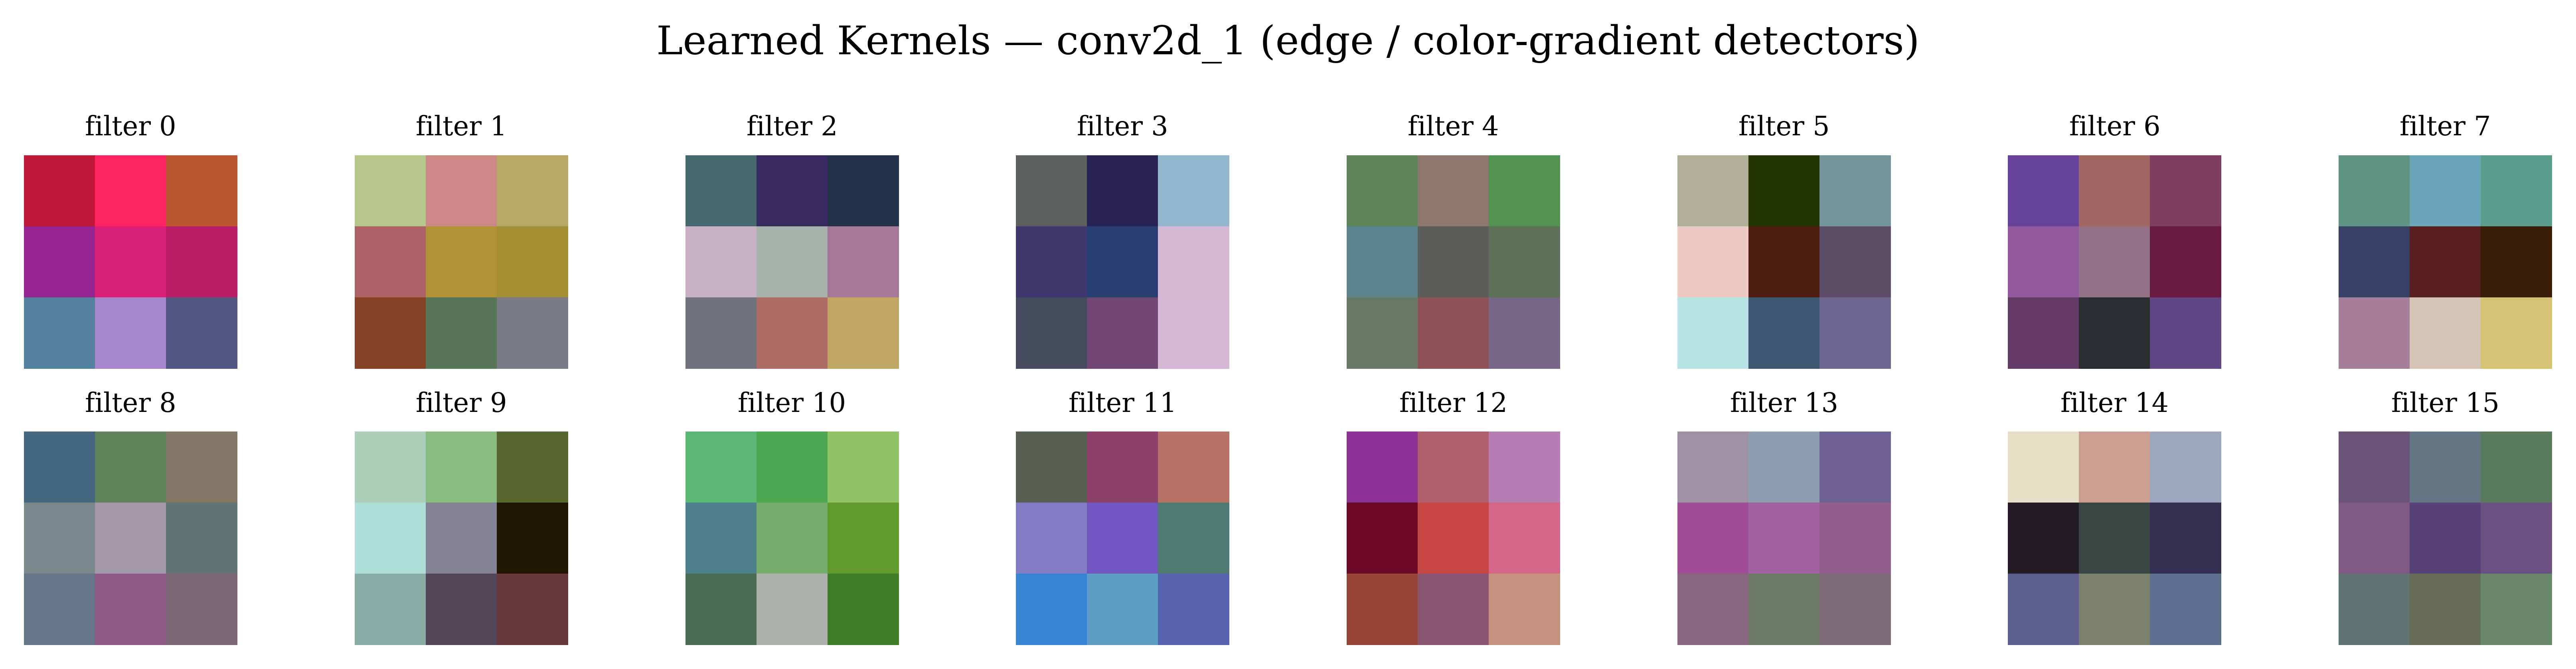

In [ ]:
# ===== CELL 14b: Learned first-layer kernel visualization =====
def visualize_first_layer_filters(model, filename="08b_first_layer_filters", n_filters=16):
    conv_layer = next(l for l in model.layers if isinstance(l, layers.Conv2D))
    filters, biases = conv_layer.get_weights()

    f_min, f_max = filters.min(), filters.max()
    filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)

    n_filters = min(n_filters, filters_norm.shape[-1])
    cols = 8
    rows = int(np.ceil(n_filters / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.4))
    for i, ax in enumerate(np.array(axes).flat):
        if i < n_filters:
            ax.imshow(filters_norm[:, :, :, i])
            ax.set_title(f"filter {i}", fontsize=8)
        ax.axis("off")
    fig.suptitle(f"Learned Kernels — {conv_layer.name} (edge / color-gradient detectors)")
    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()

visualize_first_layer_filters(baseline_model)

Saved: /content/plots/08a_feature_map_input_image.eps


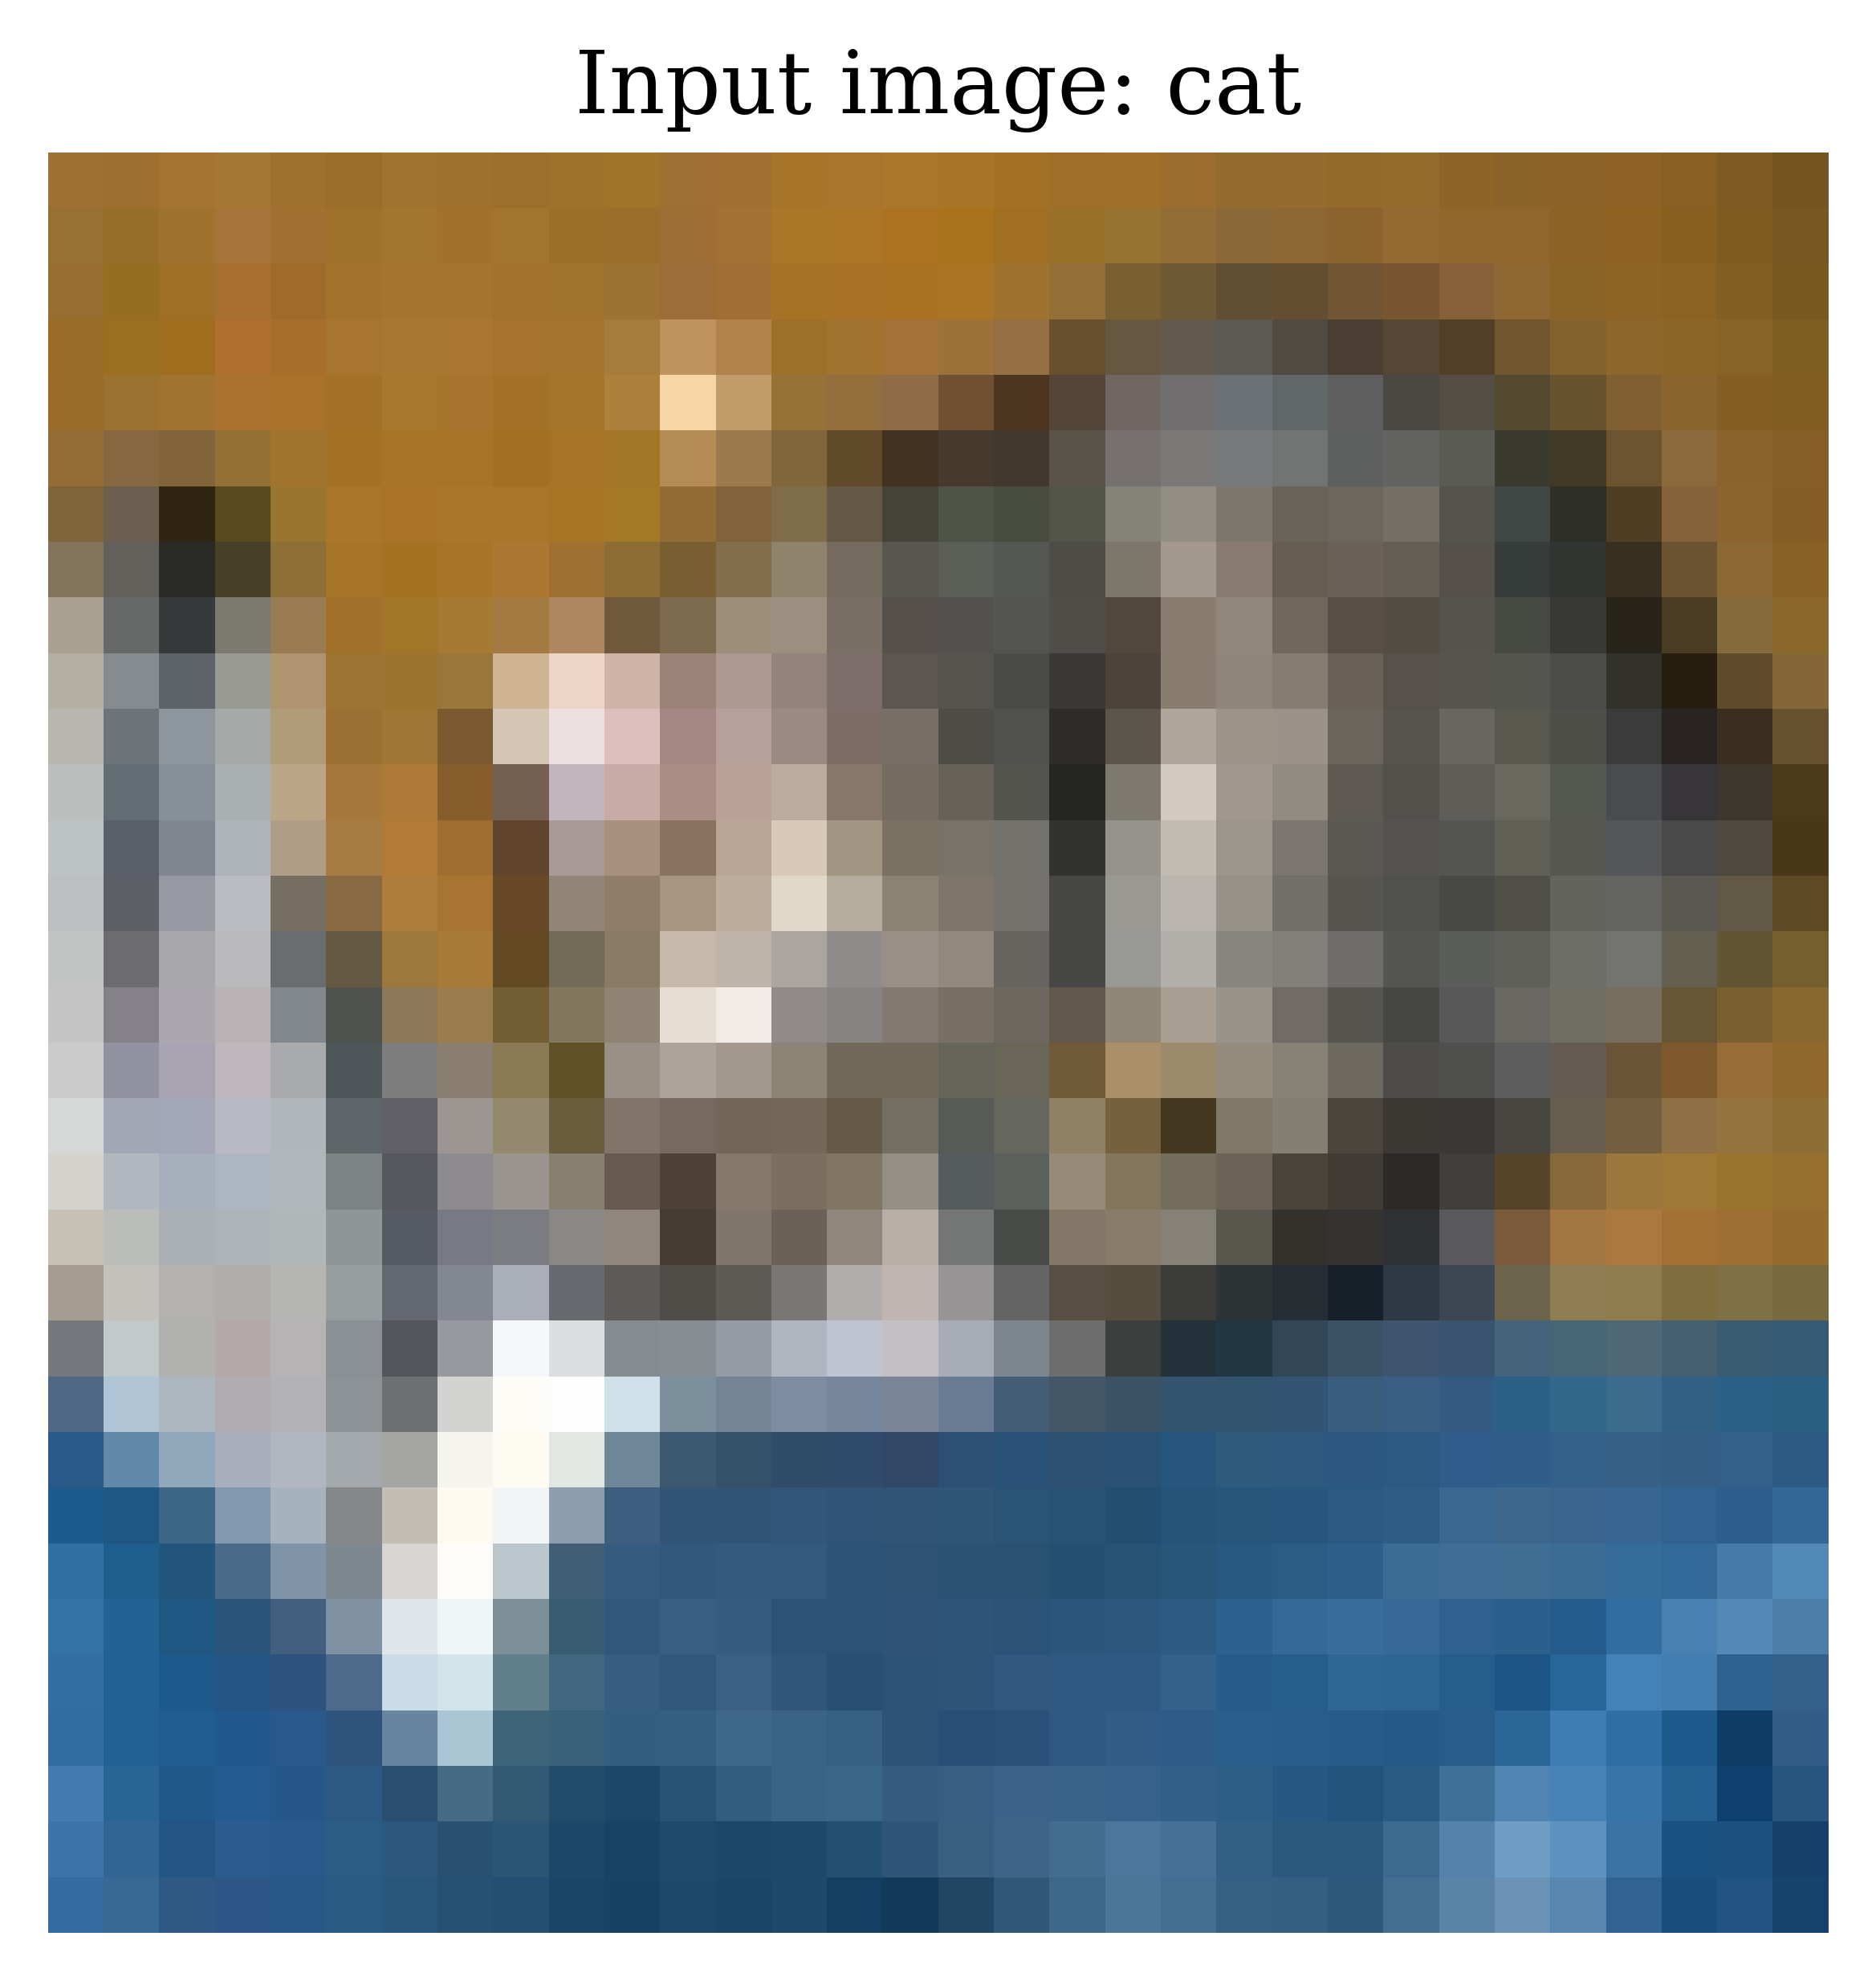

Saved: /content/plots/08c_feature_maps.eps


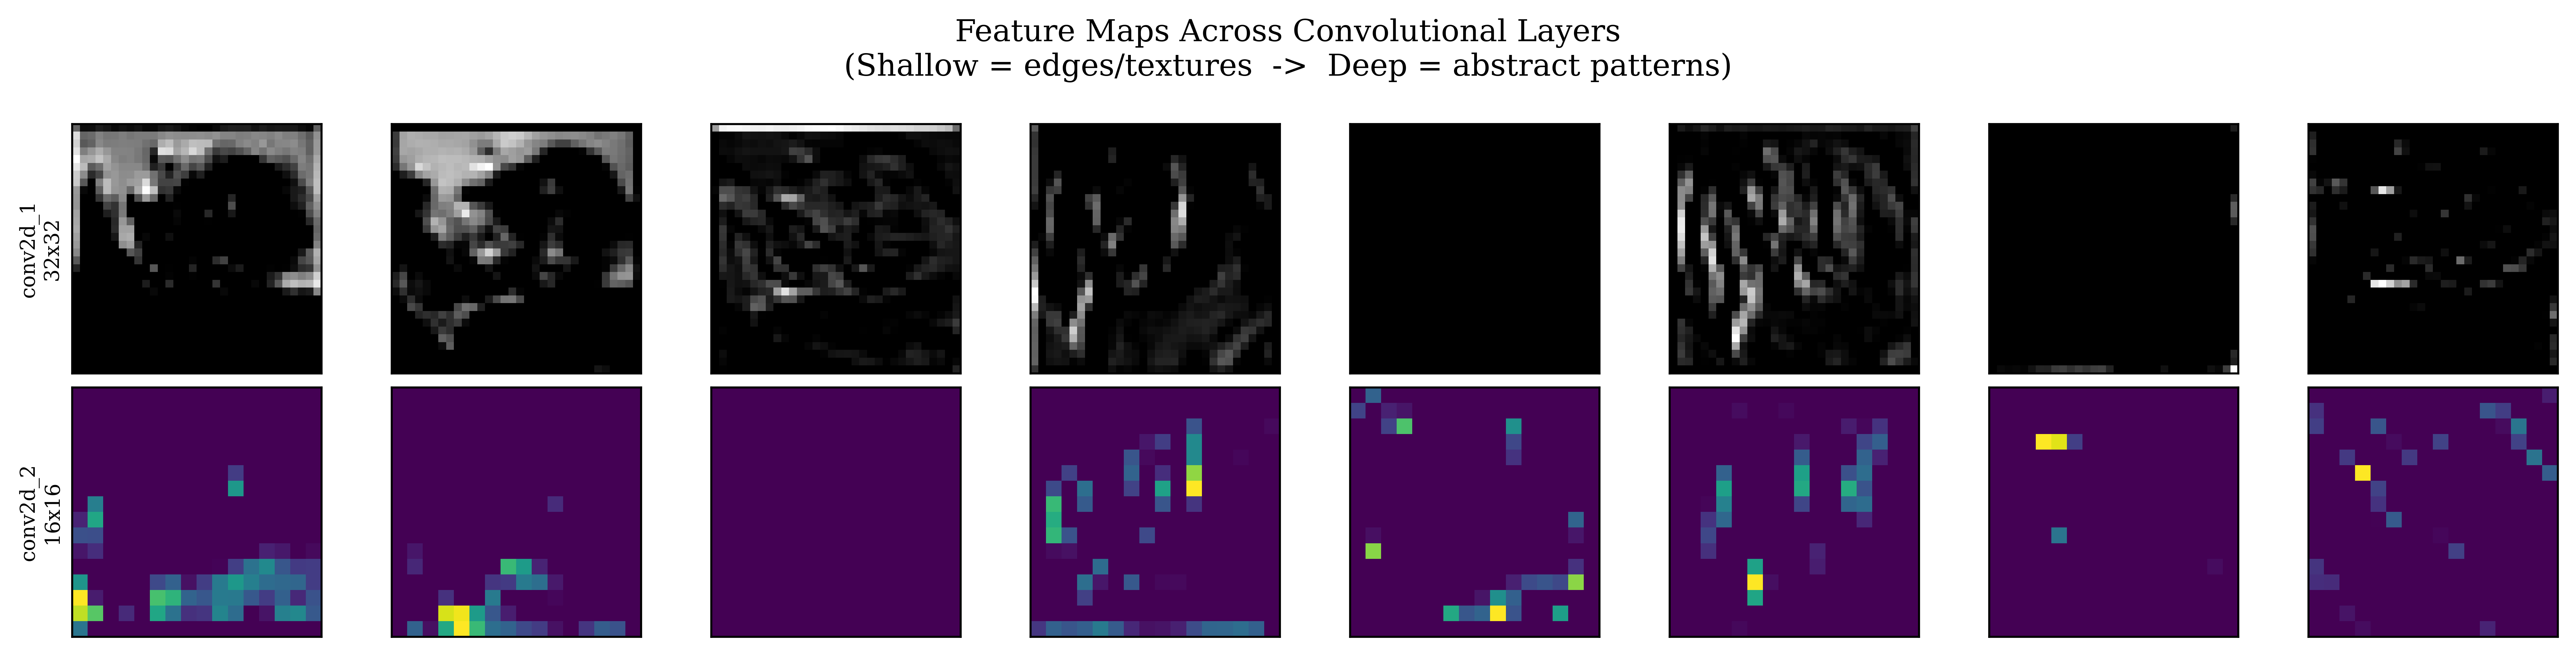

In [ ]:
# ===== CELL 14c: Feature map (activation) visualization, robust to model rebuilds =====
def visualize_feature_maps(model, image, filename="08c_feature_maps", n_filters=8):
    inp = tf.keras.Input(shape=model.input_shape[1:])
    x = inp
    conv_outputs, conv_names = [], []
    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, layers.Conv2D):
            conv_outputs.append(x)
            conv_names.append(layer.name)
    feature_model = models.Model(inputs=inp, outputs=conv_outputs)

    img_batch = np.expand_dims(image, axis=0)
    activations = feature_model.predict(img_batch, verbose=0)

    fig, axes = plt.subplots(len(conv_names), n_filters,
                              figsize=(n_filters * 1.8, len(conv_names) * 1.8))
    for row, (name, act) in enumerate(zip(conv_names, activations)):
        for col in range(n_filters):
            ax = axes[row, col]
            fmap = act[0, :, :, col]
            cmap = "gray" if row == 0 else "viridis"
            ax.imshow(fmap, cmap=cmap, interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(f"{name}\n{fmap.shape[0]}x{fmap.shape[1]}", fontsize=8)
    fig.suptitle("Feature Maps Across Convolutional Layers\n(Shallow = edges/textures  ->  Deep = abstract patterns)")
    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()

fig, ax = plt.subplots()
ax.imshow(sample_img)
ax.set_title(f"Input image: {CLASS_NAMES[y_test.flatten()[sample_idx]]}")
ax.axis("off")
save_plot(fig, "08a_feature_map_input_image")
plt.show()

visualize_feature_maps(baseline_model, sample_img)

In [ ]:
import time

def quick_train_eval(model, epochs=6, batch_size=32, tag="", x_train_data=None, y_train_data=None):
    if x_train_data is None:
        x_train_data, y_train_data = x_tr, y_tr

    start = time.perf_counter()
    h = model.fit(
        x_train_data, y_train_data,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    elapsed = time.perf_counter() - start
    val_acc = h.history["val_accuracy"][-1]
    print(f"{tag}: val_accuracy = {val_acc:.4f}, time = {elapsed:.2f}s")
    return val_acc, elapsed

experiment_results = {}


In [ ]:
kernel_results = {}

for k in [3, 5, 7]:
    model = build_cnn(kernel_size=(k, k))
    conv1_shape = tuple(model.get_layer("conv2d_1").output.shape[1:])
    conv2_shape = tuple(model.get_layer("conv2d_2").output.shape[1:])
    kernel_results[f"{k}x{k}"] = {
        "first_conv": conv1_shape,
        "second_conv": conv2_shape,
    }
    print(f"Kernel {k}x{k}: first conv {conv1_shape}, second conv {conv2_shape}")


Kernel 3x3: first conv (32, 32, 32), second conv (16, 16, 64)
Kernel 5x5: first conv (32, 32, 32), second conv (16, 16, 64)
Kernel 7x7: first conv (32, 32, 32), second conv (16, 16, 64)


In [ ]:
stride_padding_results = {}

for s in [1, 2]:
    model = build_cnn(strides=(s, s), padding="valid")
    conv1 = tuple(model.get_layer("conv2d_1").output.shape[1:])
    conv2 = tuple(model.get_layer("conv2d_2").output.shape[1:])
    stride_padding_results[f"stride_{s}"] = (conv1, conv2)
    print(f"Stride {s}, valid padding: first conv {conv1}, second conv {conv2}")

for p in ["same", "valid"]:
    model = build_cnn(strides=(1, 1), padding=p)
    conv1 = tuple(model.get_layer("conv2d_1").output.shape[1:])
    conv2 = tuple(model.get_layer("conv2d_2").output.shape[1:])
    stride_padding_results[f"padding_{p}"] = (conv1, conv2)
    print(f"Padding {p}: first conv {conv1}, second conv {conv2}")

print("Formula: floor((N - K + 2P) / S) + 1")


Stride 1, valid padding: first conv (30, 30, 32), second conv (13, 13, 64)
Stride 2, valid padding: first conv (15, 15, 32), second conv (3, 3, 64)
Padding same: first conv (32, 32, 32), second conv (16, 16, 64)
Padding valid: first conv (30, 30, 32), second conv (13, 13, 64)
Formula: floor((N - K + 2P) / S) + 1


In [ ]:
pooling_results = {}

for pool in ["max", "avg"]:
    model = build_cnn(pooling=pool)
    val_acc, elapsed = quick_train_eval(model, epochs=6, batch_size=32, tag=f"{pool}_pool")
    pool1_shape = tuple(model.get_layer("pool_1").output.shape[1:])
    pool2_shape = tuple(model.get_layer("pool_2").output.shape[1:])
    pooling_results[pool] = {
        "val_accuracy": val_acc,
        "time_seconds": elapsed,
        "pool_1_shape": pool1_shape,
        "pool_2_shape": pool2_shape,
    }
    print(f"{pool} pooling: pool_1 {pool1_shape}, pool_2 {pool2_shape}")

experiment_results["pooling"] = pooling_results


max_pool: val_accuracy = 0.6886, time = 39.66s
max pooling: pool_1 (16, 16, 32), pool_2 (8, 8, 64)
avg_pool: val_accuracy = 0.6802, time = 37.33s
avg pooling: pool_1 (16, 16, 32), pool_2 (8, 8, 64)


In [ ]:
exercise_1_output = conv_output_dim(64, 5, s=2, p=2)
exercise_2_params = (3 * 3 * 3 + 1) * 64

print(f"Exercise 1 output size: {exercise_1_output} x {exercise_1_output}")
print(f"Exercise 2 trainable parameters: {exercise_2_params}")
print("Exercise 3: ReLU outputs max(0, z), while Sigmoid outputs values in (0, 1). ReLU is used in hidden CNN layers and Sigmoid is mainly used for binary outputs.")


Exercise 1 output size: 32 x 32
Exercise 2 trainable parameters: 1792
Exercise 3: ReLU outputs max(0, z), while Sigmoid outputs values in (0, 1). ReLU is used in hidden CNN layers and Sigmoid is mainly used for binary outputs.


In [ ]:
print("Exercise 4")
for pool, values in pooling_results.items():
    print(
        f"{pool}: output sizes {values['pool_1_shape']} and {values['pool_2_shape']}, "
        f"validation accuracy {values['val_accuracy']:.4f}"
    )


Exercise 4
max: output sizes (16, 16, 32) and (8, 8, 64), validation accuracy 0.6886
avg: output sizes (16, 16, 32) and (8, 8, 64), validation accuracy 0.6802


In [ ]:
sample_size = 8000
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(x_tr), size=sample_size, replace=False)
x_sample = x_tr[sample_indices]
y_sample = y_tr[sample_indices]

filter_exercise_results = {}

for f in [16, 64]:
    model = build_cnn(filters=(f, f))
    val_acc, elapsed = quick_train_eval(
        model,
        epochs=6,
        batch_size=32,
        tag=f"{f}_filters",
        x_train_data=x_sample,
        y_train_data=y_sample,
    )
    filter_exercise_results[f] = {
        "val_accuracy": val_acc,
        "time_seconds": elapsed,
        "parameters": model.count_params(),
    }
    print(
        f"{f} filters: val_accuracy = {val_acc:.4f}, "
        f"time = {elapsed:.2f}s, parameters = {model.count_params():,}"
    )

experiment_results["filter_exercise"] = filter_exercise_results


16_filters: val_accuracy = 0.5182, time = 12.74s
16 filters: val_accuracy = 0.5182, time = 12.74s, parameters = 135,258
64_filters: val_accuracy = 0.5466, time = 13.26s
64 filters: val_accuracy = 0.5466, time = 13.26s, parameters = 564,426


/tmp/ipykernel_655/2807195355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette="mako", ax=ax)


Saved: /content/plots/09_experiment_comparison.eps


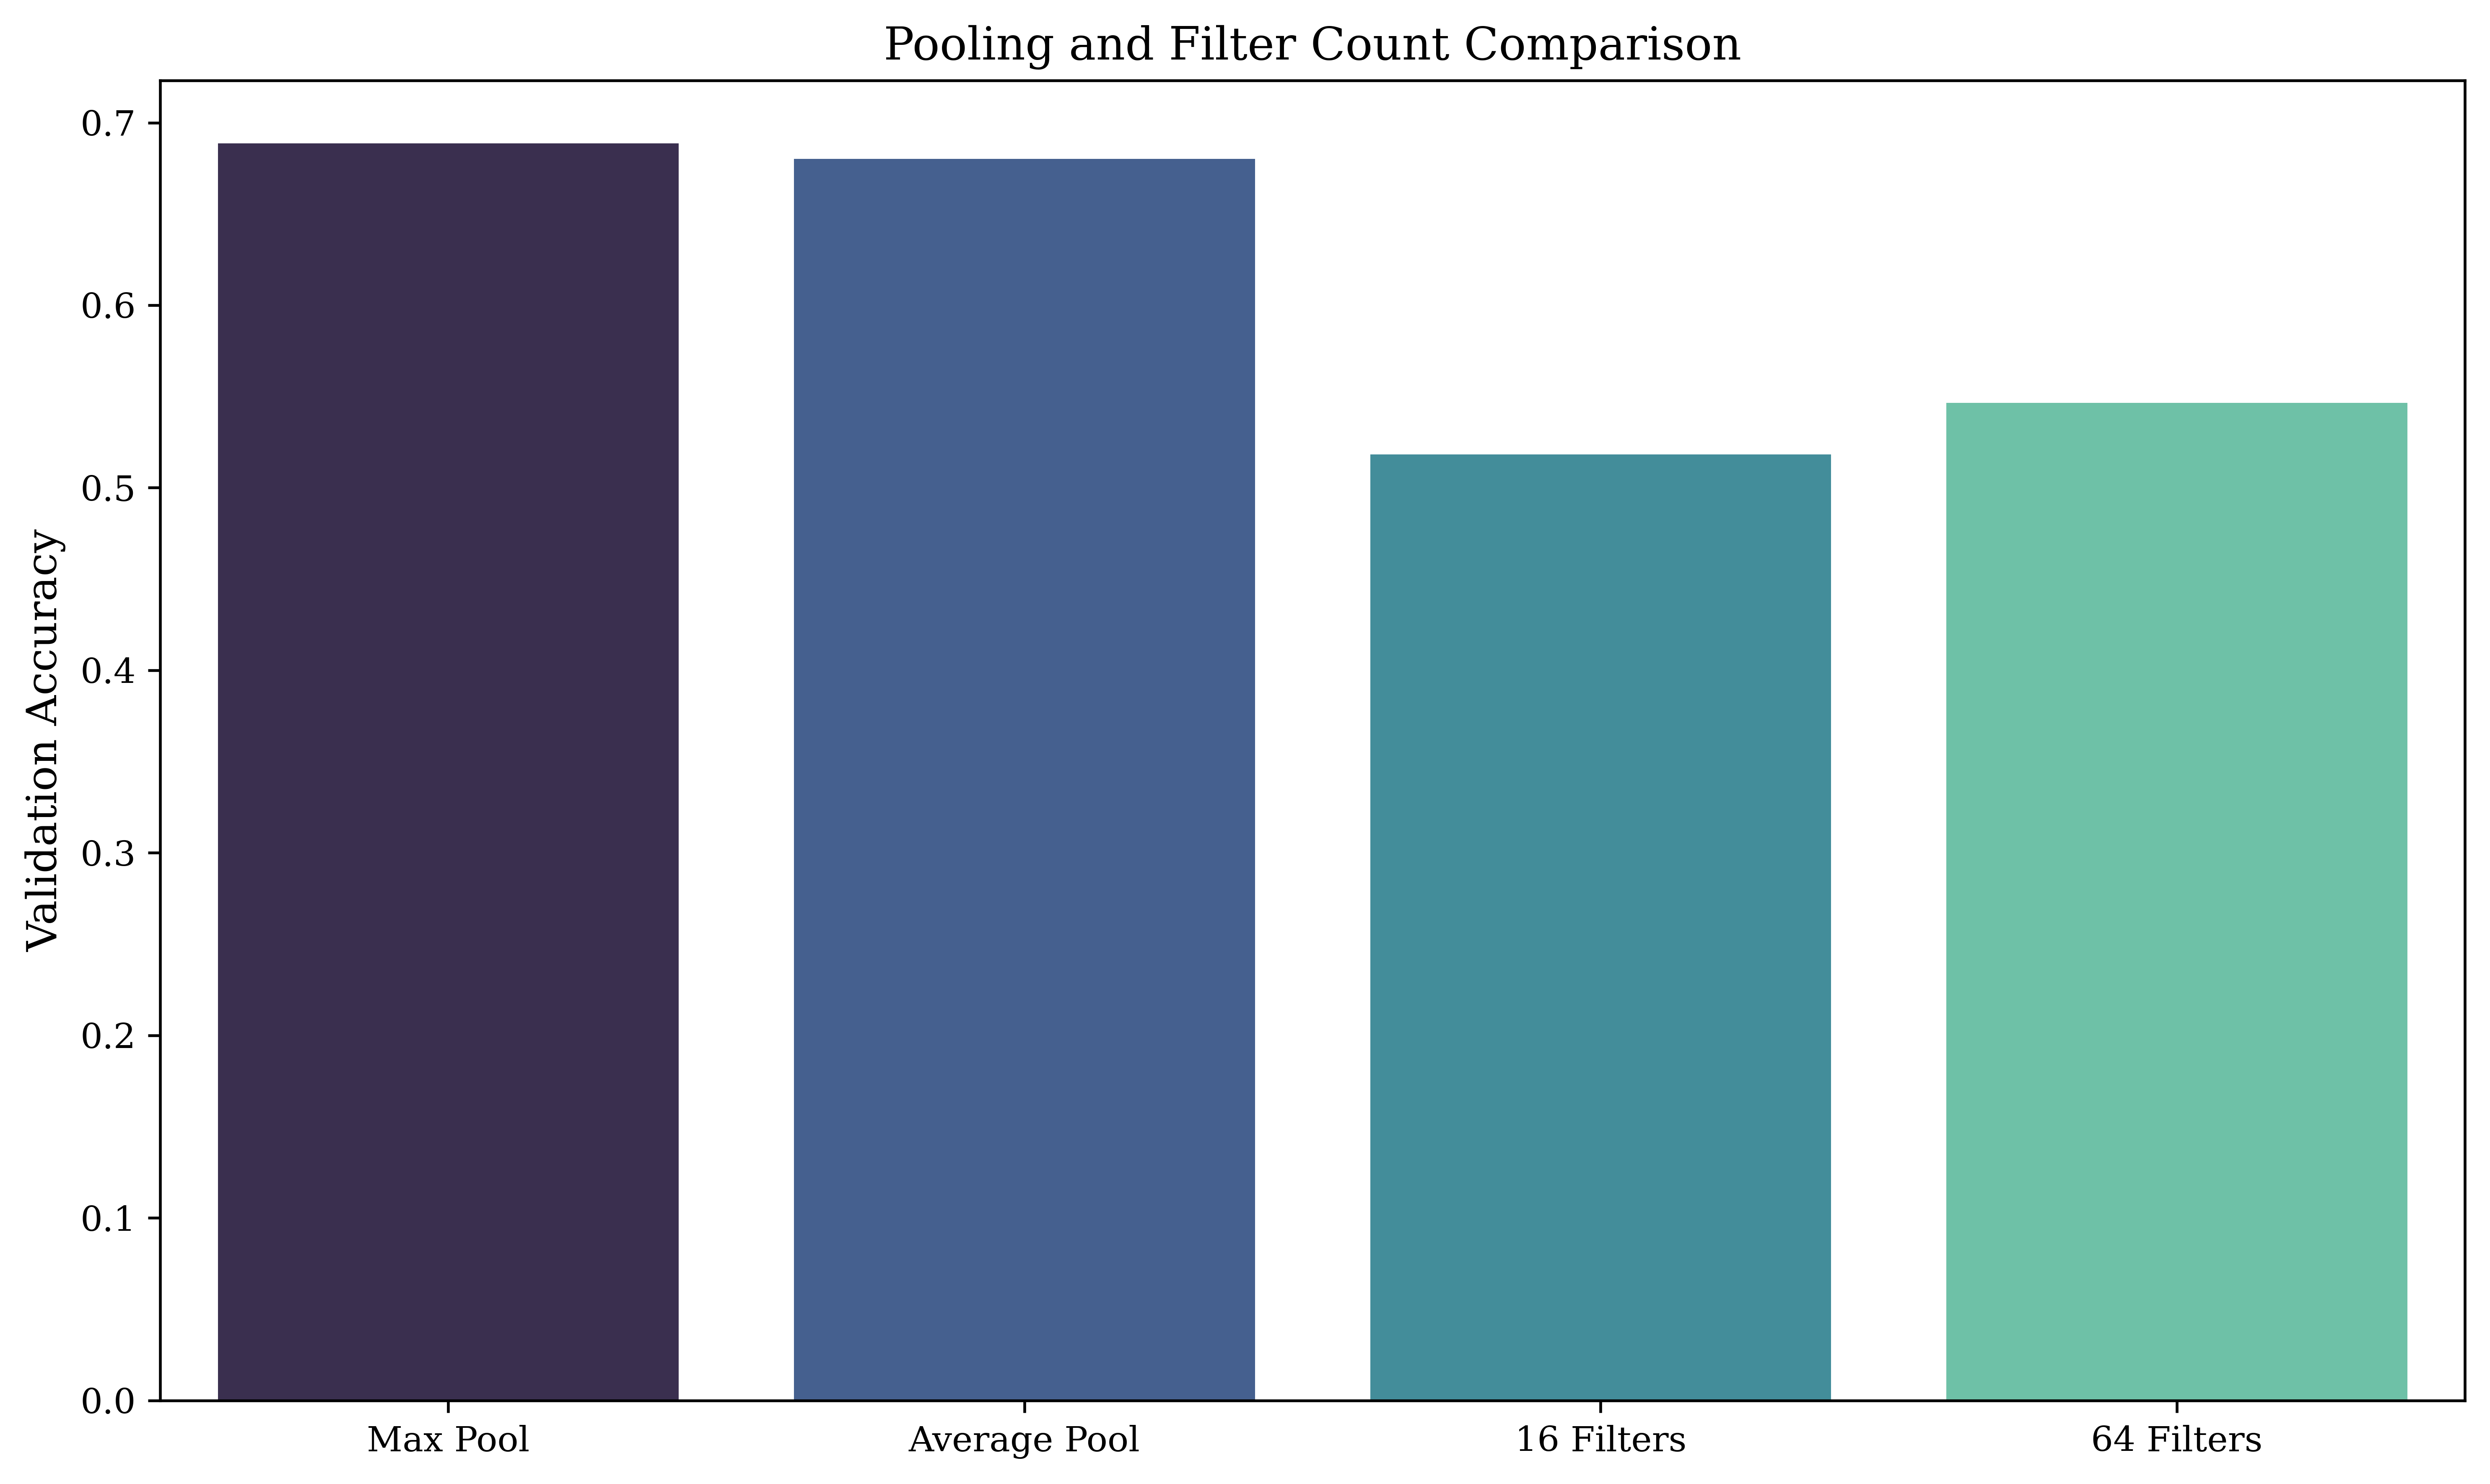

In [ ]:
labels = ["Max Pool", "Average Pool", "16 Filters", "64 Filters"]
values = [
    pooling_results["max"]["val_accuracy"],
    pooling_results["avg"]["val_accuracy"],
    filter_exercise_results[16]["val_accuracy"],
    filter_exercise_results[64]["val_accuracy"],
]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=labels, y=values, palette="mako", ax=ax)
ax.set_ylabel("Validation Accuracy")
ax.set_title("Pooling and Filter Count Comparison")
fig.tight_layout()
save_plot(fig, "09_experiment_comparison")
plt.show()


In [ ]:
with open(os.path.join(PLOT_DIR, "10_experiment_results.txt"), "w") as f:
    f.write("Kernel size feature map comparison\n")
    for k, values in kernel_results.items():
        line = f"{k}: first conv {values['first_conv']}, second conv {values['second_conv']}\n"
        f.write(line)
        print(line, end="")

    f.write("\nStride and padding output dimensions\n")
    for key, values in stride_padding_results.items():
        line = f"{key}: first conv {values[0]}, second conv {values[1]}\n"
        f.write(line)
        print(line, end="")

    f.write("\nPooling comparison\n")
    for pool, values in pooling_results.items():
        line = (
            f"{pool}: pool_1 {values['pool_1_shape']}, pool_2 {values['pool_2_shape']}, "
            f"val_accuracy {values['val_accuracy']:.4f}\n"
        )
        f.write(line)
        print(line, end="")

    f.write("\nAdditional exercises\n")
    f.write(f"Exercise 1 output size: {exercise_1_output} x {exercise_1_output}\n")
    f.write(f"Exercise 2 trainable parameters: {exercise_2_params}\n")
    f.write("Exercise 3: ReLU vs Sigmoid comparison completed\n")
    f.write("Exercise 4: Max vs Average Pooling comparison completed\n")

    for fcount, values in filter_exercise_results.items():
        line = (
            f"{fcount} filters: val_accuracy {values['val_accuracy']:.4f}, "
            f"time {values['time_seconds']:.2f}s, parameters {values['parameters']:,}\n"
        )
        f.write(line)
        print(line, end="")


3x3: first conv (32, 32, 32), second conv (16, 16, 64)
5x5: first conv (32, 32, 32), second conv (16, 16, 64)
7x7: first conv (32, 32, 32), second conv (16, 16, 64)
stride_1: first conv (30, 30, 32), second conv (13, 13, 64)
stride_2: first conv (15, 15, 32), second conv (3, 3, 64)
padding_same: first conv (32, 32, 32), second conv (16, 16, 64)
padding_valid: first conv (30, 30, 32), second conv (13, 13, 64)
max: pool_1 (16, 16, 32), pool_2 (8, 8, 64), val_accuracy 0.6886
avg: pool_1 (16, 16, 32), pool_2 (8, 8, 64), val_accuracy 0.6802
16 filters: val_accuracy 0.5182, time 12.74s, parameters 135,258
64 filters: val_accuracy 0.5466, time 13.26s, parameters 564,426


In [ ]:
# ===== CELL 17: Zip and download all plots/reports =====
import shutil
from google.colab import files

zip_path = "/content/cnn_cifar10_lab_outputs"
shutil.make_archive(zip_path, 'zip', PLOT_DIR)

print("Files in archive:")
for f in sorted(os.listdir(PLOT_DIR)):
    print(" -", f)

files.download(zip_path + ".zip")


Files in archive:
 - 01_class_distribution_train.eps
 - 02_class_distribution_test.eps
 - 03_sample_images.eps
 - 04_trainable_params.txt
 - 05_training_curves.eps
 - 06_classification_report.txt
 - 07_confusion_matrix.eps
 - 08_sobel_edges.eps
 - 08a_feature_map_input_image.eps
 - 08b_first_layer_filters.eps
 - 08c_feature_maps.eps
 - 09_experiment_comparison.eps
 - 10_experiment_results.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>